# Proyek Analisis Data: Air Quality
- Kelompok Ke 4 Dari Kelas IF 3:
- Anggota : </br>
10123087 - Haafiz Dauz Syahputra</br>
10123089 - Dionisius Deni Mardiansyah</br>
10123096 - Muhammad Hafiz Hafiyyan</br>
10123103 - Muhamad Haikal</br>
10123109 - Muhammad Harlan Fadhillah</br>
10123128 - Saadilah Fahmi Husaini</br>



## A. Menentukan Pertanyaan Bisnis

- Arah angin mana yang paling sering memengaruhi kualitas udara di semua stasiun? - 10123087 - Haafiz Dauz Syahputra</br>
- Bagaimana pengaruh kecepatan dan arah angin terhadap penyebaran polutan di stasiun Tiantan selama tahun 2016? - 10123089 - Dionisius Deni Mardiansyah</br>
- Apakah suhu udara ("temp") di stasiun Tiantan memengaruhi kualitas udara? - 10123096 - Muhammad Hafiz Hafiyyan</br>
- Stasiun mana saja yang memiliki kualitas udara terburuk pada tahun 2016? - 10123103 - Muhamad Haikal</br>
- Apakah terdapat hubungan antara curah hujan dengan kadar PM10 di stasiun Aotizhongxin selama tahun 2016? - 10123109 - Muhammad Harlan Fadhillah</br>
- Bagaimana pengaruh hujan terhadap kualitas udara? Jika partikel polutan mengalami penurunan, partikel mana yang mengalami penurunan paling signifikan saat hujan - 10123128 - Saadilah Fahmi Husaini</br>

## B. Menyiapkan semua library yang dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

## C. Data Wrangling

### 1. Gathering Data

In [3]:
# Mendefinisikan daftar nilai yang dianggap sebagai missing values
missing_value_format = ['N.A', 'na', 'n.a.','n/a','?','-']

# Membaca data dari CSV ke dalam DataFrame
df_aotizhongxin  = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv', na_values = missing_value_format)
df_changping     = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv', na_values = missing_value_format)
df_dingling      = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv', na_values = missing_value_format)
df_dongsi        = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv', na_values = missing_value_format)
df_guanyuan      = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv', na_values = missing_value_format)
df_gucheng       = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv', na_values = missing_value_format)
df_huairou       = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv', na_values = missing_value_format)
df_nongzhanguan  = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv', na_values = missing_value_format)
df_shunyi        = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv', na_values = missing_value_format)
df_tiantan       = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv', na_values = missing_value_format)
df_wanliu        = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv', na_values = missing_value_format)
df_wanshouxigong = pd.read_csv('PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv', na_values = missing_value_format)

# Membuat daftar semua DataFrame
dataframes = [
    df_aotizhongxin, df_changping, df_dingling, df_dongsi, df_guanyuan,
    df_gucheng, df_huairou, df_nongzhanguan, df_shunyi, df_tiantan,
    df_wanliu, df_wanshouxigong
]


### 2. Assessing Data

#### a. Station Aotizhongxin

- Menampilkan Data <b><i>Station Aotizhongxin</b></i>  

In [3]:
df_aotizhongxin

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4,Aotizhongxin
35060,35061,2017,2,28,20,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Aotizhongxin
35061,35062,2017,2,28,21,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1,Aotizhongxin
35062,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin


- Identifikasi <b><i>Missing Values</b></i>

In [4]:
# Menampilkan Struktur Data Dari DataSet Station Aotizhongxin 
df_aotizhongxin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.139 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>935 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [5]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_aotizhongxin.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

- Identifikasi <b><i>Data Duplicate</b></i>

In [6]:
df_aotizhongxin.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### b. Station Changping

- Menampilkan Data <b><i>Station Changping</b></i>  

In [7]:
df_changping

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping
35060,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping
35061,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping
35062,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping


- Identifikasi <b><i>Missing Values</b></i>

In [8]:
# Menampilkan Struktur Data Dari DataSet Station Changping
df_changping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.290 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>774 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [9]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_changping.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       774
PM10        582
SO2         628
NO2         667
CO         1521
O3          604
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [10]:
df_changping.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### c. Station Dingling

- Menampilkan Data <b><i>Station Dingling</b></i>  

In [11]:
df_dingling

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling
35060,35061,2017,2,28,20,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1,Dingling
35061,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling
35062,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling


Identifikasi <b><i>Missing Values</b></i>

In [12]:
# Menampilkan Struktur Data Dari DataSet Station Dingling
df_dingling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.285 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>779 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [13]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_dingling.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       779
PM10        656
SO2         730
NO2        1234
CO         2012
O3         1214
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [14]:
df_dingling.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### d. Station Dongsi

- Menampilkan Data <b><i>Station Dongsi</b></i>  

In [15]:
df_dongsi

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
35060,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
35061,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
35062,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


Identifikasi <b><i>Missing Values</b></i>

In [16]:
# Menampilkan Struktur Data Dari DataSet Station Dongsi
df_dongsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.314 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>750 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [17]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_dongsi.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       750
PM10        553
SO2         663
NO2        1601
CO         3197
O3          664
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [18]:
df_dongsi.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### e. Station Guanyuan

- Menampilkan Data <b><i>Station Guanyuan</b></i>  

In [19]:
df_guanyuan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
35060,35061,2017,2,28,20,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
35061,35062,2017,2,28,21,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
35062,35063,2017,2,28,22,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


Identifikasi <b><i>Missing Values</b></i>

In [20]:
# Menampilkan Struktur Data Dari DataSet Station Guanyuan
df_guanyuan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.448 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>616 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [21]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_guanyuan.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [22]:
df_guanyuan.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### f. Station Gucheng

- Menampilkan Data <b><i>Station Guanyuan</b></i>  

In [23]:
df_gucheng

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,14.0,58.0,4.0,19.0,500.0,56.0,12.8,1009.9,-17.0,0.0,NNW,3.1,Gucheng
35060,35061,2017,2,28,20,27.0,83.0,6.0,60.0,700.0,26.0,11.1,1010.4,-15.5,0.0,NW,1.9,Gucheng
35061,35062,2017,2,28,21,22.0,37.0,7.0,52.0,600.0,27.0,10.5,1010.8,-15.9,0.0,N,2.3,Gucheng
35062,35063,2017,2,28,22,9.0,23.0,3.0,13.0,400.0,57.0,8.9,1010.9,-14.9,0.0,NE,1.6,Gucheng


Identifikasi <b><i>Missing Values</b></i>

In [24]:
# Menampilkan Struktur Data Dari DataSet Station Gucheng
df_gucheng.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.418 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>646 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [25]:
# Menghitung Jumlah Missing Value Seluruh Baris
df_gucheng.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       646
PM10        381
SO2         507
NO2         668
CO         1401
O3          729
TEMP         51
PRES         50
DEWP         51
RAIN         43
wd          159
WSPM         42
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [26]:
df_gucheng.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### g. Station Huairou

- Menampilkan Data <b><i>Station Huairou</b></i>  

In [27]:
df_huairou

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


Identifikasi <b><i>Missing Values</b></i>

In [28]:
df_huairou.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34111 non-null  float64
 6   PM10     34287 non-null  float64
 7   SO2      34084 non-null  float64
 8   NO2      33425 non-null  float64
 9   CO       33642 non-null  float64
 10  O3       33913 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35011 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35009 non-null  float64
 15  wd       34762 non-null  object 
 16  WSPM     35015 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.111 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>953 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [29]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_huairou.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       953
PM10        777
SO2         980
NO2        1639
CO         1422
O3         1151
TEMP         51
PRES         53
DEWP         53
RAIN         55
wd          302
WSPM         49
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [30]:
df_huairou.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### h. Station Nongzhanguan 

- Menampilkan Data <b><i>Station Nongzhanguan</b></i>  

In [31]:
df_nongzhanguan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Nongzhanguan
35060,35061,2017,2,28,20,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Nongzhanguan
35061,35062,2017,2,28,21,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,NW,1.1,Nongzhanguan
35062,35063,2017,2,28,22,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Nongzhanguan


Identifikasi <b><i>Missing Values</b></i>

In [32]:
# Menampilkan Struktur Data Dari DataSet Station Nongzhanguan
df_nongzhanguan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.436 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>628 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [33]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_nongzhanguan.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [34]:
df_nongzhanguan.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### i. Station Shunyi 

- Menampilkan Data <b><i>Station Shunyi</b></i>  

In [35]:
df_shunyi

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
35060,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
35061,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
35062,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


Identifikasi <b><i>Missing Values</b></i>

In [36]:
# Menampilkan Struktur Data Dari DataSet Shunyi
df_shunyi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34151 non-null  float64
 6   PM10     34516 non-null  float64
 7   SO2      33768 non-null  float64
 8   NO2      33699 non-null  float64
 9   CO       32886 non-null  float64
 10  O3       33575 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35013 non-null  float64
 13  DEWP     35010 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34581 non-null  object 
 16  WSPM     35020 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.151 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>913 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [37]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_shunyi.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       913
PM10        548
SO2        1296
NO2        1365
CO         2178
O3         1489
TEMP         51
PRES         51
DEWP         54
RAIN         51
wd          483
WSPM         44
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [38]:
df_shunyi.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### j. Station Tiantan 

- Menampilkan Data <b><i>Station Tiantan</b></i>  

In [39]:
df_tiantan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,20.0,48.0,2.0,NaN,500.0,NaN,12.5,1013.5,-16.2,0.0,NW,2.4,Tiantan
35060,35061,2017,2,28,20,11.0,34.0,3.0,36.0,500.0,NaN,11.6,1013.6,-15.1,0.0,WNW,0.9,Tiantan
35061,35062,2017,2,28,21,18.0,32.0,4.0,48.0,500.0,48.0,10.8,1014.2,-13.3,0.0,NW,1.1,Tiantan
35062,35063,2017,2,28,22,15.0,42.0,5.0,52.0,600.0,44.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Tiantan


Identifikasi <b><i>Missing Values</b></i>

In [40]:
# Menampilkan Struktur Data Dari DataSet Station Tiantan
df_tiantan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.387 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>677 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>



In [41]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_tiantan.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       677
PM10        597
SO2        1118
NO2         744
CO         1126
O3          843
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [42]:
df_tiantan.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### k. Station Wanliu 

- Menampilkan Data <b><i>Station Wanliu</b></i>  

In [43]:
df_wanliu

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,11.0,27.0,4.0,20.0,300.0,81.0,12.6,1011.9,-14.3,0.0,N,2.0,Wanliu
35060,35061,2017,2,28,20,15.0,43.0,6.0,55.0,500.0,45.0,9.4,1012.3,-11.9,0.0,WSW,1.0,Wanliu
35061,35062,2017,2,28,21,13.0,35.0,7.0,48.0,500.0,48.0,8.7,1012.8,-13.7,0.0,N,1.1,Wanliu
35062,35063,2017,2,28,22,12.0,31.0,5.0,47.0,500.0,50.0,7.8,1012.9,-12.6,0.0,NNE,1.0,Wanliu


Identifikasi <b><i>Missing Values</b></i>

In [44]:
# Menampilkan Struktur Data Dari DataSet Station Wanliu
df_wanliu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.682 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>382 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [45]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_wanliu.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [46]:
df_wanliu.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

#### l. Station Wanshouxigong 

- Menampilkan Data <b><i>Station Wanshouxigong</b></i>  

In [47]:
df_wanshouxigong

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
35060,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
35061,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
35062,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


Identifikasi <b><i>Missing Values</b></i>

In [48]:
# Menampilkan Struktur Data Dari DataSet Station Wanshouxigong
df_wanshouxigong.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34368 non-null  float64
 6   PM10     34580 non-null  float64
 7   SO2      34395 non-null  float64
 8   NO2      34310 non-null  float64
 9   CO       33767 non-null  float64
 10  O3       33986 non-null  float64
 11  TEMP     35045 non-null  float64
 12  PRES     35045 non-null  float64
 13  DEWP     35045 non-null  float64
 14  RAIN     35045 non-null  float64
 15  wd       34985 non-null  object 
 16  WSPM     35051 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Berdasarkan output dari perintah info(), dapat diketahui bahwa beberapa kolom dalam dataset memiliki nilai hilang (missing values).
Sebagai contoh, kolom <b>"PM2.5"</b> memiliki <b>34.368 baris</b> dengan data valid dari total <b>35.064 baris.</b>
Hal ini menunjukkan bahwa terdapat <b>696 baris</b> pada kolom <b>"PM2.5"</b> yang mengandung nilai hilang <i><b>(missing values).</b></i>

In [49]:
# Menghitung Jumlah Missing Value Seluruh Baris   
df_wanshouxigong.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       696
PM10        484
SO2         669
NO2         754
CO         1297
O3         1078
TEMP         19
PRES         19
DEWP         19
RAIN         19
wd           79
WSPM         13
station       0
dtype: int64

Mendapatkan seluruh baris yang mengandung <i>missing values</i>

Identifikasi <b><i>Data Duplicate</b></i>

In [50]:
df_wanshouxigong.duplicated().values.any()

np.False_

Dari output tersebut menunjukan bahwa data <b>tidak mangandung <i>data duplicate</i></b>

### 3. Cleaning Data

#### a. Station Aotizhongxin

Menghapus <b><i>Missing Values</i></b>

In [51]:
df_aotizhongxin.dropna(axis=0, inplace=True)
df_aotizhongxin.reset_index(drop=True, inplace=True)
df_aotizhongxin

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31810,35060,2017,2,28,19,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4,Aotizhongxin
31811,35061,2017,2,28,20,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Aotizhongxin
31812,35062,2017,2,28,21,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1,Aotizhongxin
31813,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin


#### b. Station Changping

Menghapus <b><i>Missing Values</i></b>

In [52]:
df_changping.dropna(axis=0, inplace=True)
df_changping.reset_index(drop=True, inplace=True)
df_changping

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32676,35058,2017,2,28,17,18.0,61.0,6.0,29.0,400.0,51.0,14.7,1007.4,-12.6,0.0,WNW,4.2,Changping
32677,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping
32678,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping
32679,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping


#### c. Station Dingling

Menghapus <b><i>Missing Values</i></b>

In [53]:
df_dingling.dropna(axis=0, inplace=True)
df_dingling.reset_index(drop=True, inplace=True)
df_dingling

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
1,6,2013,3,1,5,6.0,6.0,3.0,4.0,200.0,79.0,-4.5,1022.6,-19.5,0.0,NNW,1.7,Dingling
2,7,2013,3,1,6,5.0,10.0,3.0,4.0,200.0,77.0,-4.5,1023.4,-19.5,0.0,NNW,1.8,Dingling
3,8,2013,3,1,7,5.0,6.0,3.0,2.0,200.0,80.0,-2.1,1024.6,-20.0,0.0,NW,2.5,Dingling
4,9,2013,3,1,8,8.0,7.0,3.0,3.0,200.0,79.0,-0.2,1025.2,-20.5,0.0,NNW,2.8,Dingling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31301,35060,2017,2,28,19,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling
31302,35061,2017,2,28,20,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1,Dingling
31303,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling
31304,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling


#### d. Station Dongsi

Menghapus <b><i>Missing Values</i></b>

In [54]:
df_dongsi.dropna(axis=0, inplace=True)
df_dongsi.reset_index(drop=True, inplace=True)
df_dongsi

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,6,2013,3,1,5,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
3,7,2013,3,1,6,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
4,8,2013,3,1,7,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30333,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
30334,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
30335,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
30336,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


#### e. Station Guanyuan

Menghapus <b><i>Missing Values</i></b>

In [55]:
df_guanyuan.dropna(axis=0, inplace=True)
df_guanyuan.reset_index(drop=True, inplace=True)
df_guanyuan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32258,35060,2017,2,28,19,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
32259,35061,2017,2,28,20,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
32260,35062,2017,2,28,21,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
32261,35063,2017,2,28,22,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


#### f. Station Gucheng

Menghapus <b><i>Missing Values</i></b>

In [56]:
df_gucheng.dropna(axis=0, inplace=True)
df_gucheng.reset_index(drop=True, inplace=True)
df_gucheng

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,21,2013,3,1,20,13.0,25.0,12.0,5.0,1100.0,61.0,1.6,1027.1,-18.4,0.0,ESE,1.9,Gucheng
1,22,2013,3,1,21,15.0,23.0,14.0,13.0,1200.0,52.0,1.0,1028.1,-17.4,0.0,SSE,0.7,Gucheng
2,23,2013,3,1,22,16.0,28.0,16.0,19.0,1200.0,45.0,1.3,1028.4,-17.6,0.0,E,1.0,Gucheng
3,24,2013,3,1,23,16.0,28.0,14.0,20.0,1100.0,44.0,0.2,1028.6,-17.6,0.0,ESE,1.1,Gucheng
4,25,2013,3,2,0,14.0,18.0,24.0,43.0,1399.0,25.0,-0.3,1028.9,-18.0,0.0,ENE,1.4,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32499,35060,2017,2,28,19,14.0,58.0,4.0,19.0,500.0,56.0,12.8,1009.9,-17.0,0.0,NNW,3.1,Gucheng
32500,35061,2017,2,28,20,27.0,83.0,6.0,60.0,700.0,26.0,11.1,1010.4,-15.5,0.0,NW,1.9,Gucheng
32501,35062,2017,2,28,21,22.0,37.0,7.0,52.0,600.0,27.0,10.5,1010.8,-15.9,0.0,N,2.3,Gucheng
32502,35063,2017,2,28,22,9.0,23.0,3.0,13.0,400.0,57.0,8.9,1010.9,-14.9,0.0,NE,1.6,Gucheng


#### g. Station Huairou

Menghapus <b><i>Missing Values</i></b>

In [57]:
df_huairou.dropna(axis=0, inplace=True)
df_huairou.reset_index(drop=True, inplace=True)
df_huairou

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,6,2013,3,1,5,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
2,7,2013,3,1,6,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
3,8,2013,3,1,7,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
4,9,2013,3,1,8,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31703,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
31704,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
31705,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
31706,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


#### h. Station Nongzhanguan 

Menghapus <b><i>Missing Values</i></b>

In [58]:
df_nongzhanguan.dropna(axis=0, inplace=True)
df_nongzhanguan.reset_index(drop=True, inplace=True)
df_nongzhanguan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33109,35060,2017,2,28,19,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Nongzhanguan
33110,35061,2017,2,28,20,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Nongzhanguan
33111,35062,2017,2,28,21,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,NW,1.1,Nongzhanguan
33112,35063,2017,2,28,22,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Nongzhanguan


#### i. Station Shunyi 

Menghapus <b><i>Missing Values</i></b>

In [59]:
df_shunyi.dropna(axis=0, inplace=True)
df_shunyi.reset_index(drop=True, inplace=True)
df_shunyi

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,6,2013,3,1,5,11.0,11.0,3.0,7.0,200.0,45.0,-2.8,1028.2,-22.1,0.0,NNW,1.7,Shunyi
3,7,2013,3,1,6,12.0,12.0,3.0,9.0,300.0,74.0,-4.0,1029.0,-21.2,0.0,NNE,1.6,Shunyi
4,8,2013,3,1,7,13.0,13.0,3.0,23.0,300.0,59.0,-2.4,1030.5,-21.3,0.0,NE,1.7,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30189,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
30190,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
30191,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
30192,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


#### j. Station Tiantan 

Menghapus <b><i>Missing Values</i></b>

In [60]:
df_tiantan.dropna(axis=0, inplace=True)
df_tiantan.reset_index(drop=True, inplace=True)
df_tiantan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32838,35056,2017,2,28,15,9.0,9.0,2.0,22.0,300.0,91.0,15.4,1013.0,-15.0,0.0,NNW,3.3,Tiantan
32839,35057,2017,2,28,16,10.0,29.0,3.0,21.0,300.0,94.0,14.9,1012.6,-15.4,0.0,NW,2.1,Tiantan
32840,35062,2017,2,28,21,18.0,32.0,4.0,48.0,500.0,48.0,10.8,1014.2,-13.3,0.0,NW,1.1,Tiantan
32841,35063,2017,2,28,22,15.0,42.0,5.0,52.0,600.0,44.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Tiantan


#### k. Station Wanliu 

Menghapus <b><i>Missing Values</i></b>

In [61]:
df_wanliu.dropna(axis=0, inplace=True)
df_wanliu.reset_index(drop=True, inplace=True)
df_wanliu

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,6,2013,3,1,5,3.0,6.0,8.0,17.0,300.0,54.0,-2.2,1025.6,-19.6,0.0,N,3.7,Wanliu
3,7,2013,3,1,6,3.0,3.0,10.0,21.0,300.0,52.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Wanliu
4,8,2013,3,1,7,3.0,6.0,11.0,26.0,300.0,47.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Wanliu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30629,35060,2017,2,28,19,11.0,27.0,4.0,20.0,300.0,81.0,12.6,1011.9,-14.3,0.0,N,2.0,Wanliu
30630,35061,2017,2,28,20,15.0,43.0,6.0,55.0,500.0,45.0,9.4,1012.3,-11.9,0.0,WSW,1.0,Wanliu
30631,35062,2017,2,28,21,13.0,35.0,7.0,48.0,500.0,48.0,8.7,1012.8,-13.7,0.0,N,1.1,Wanliu
30632,35063,2017,2,28,22,12.0,31.0,5.0,47.0,500.0,50.0,7.8,1012.9,-12.6,0.0,NNE,1.0,Wanliu


#### l. Station Wanshouxigong 

Menghapus <b><i>Missing Values</i></b>

In [62]:
df_wanshouxigong.dropna(axis=0, inplace=True)
df_wanshouxigong.reset_index(drop=True, inplace=True)
df_wanshouxigong

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,6,2013,3,1,5,10.0,10.0,4.0,8.0,200.0,64.0,-1.6,1024.7,-21.1,0.0,NE,2.0,Wanshouxigong
3,7,2013,3,1,6,8.0,8.0,6.0,13.0,300.0,61.0,-2.4,1025.4,-20.3,0.0,NE,2.3,Wanshouxigong
4,8,2013,3,1,7,8.0,8.0,8.0,20.0,300.0,54.0,-0.8,1026.7,-19.9,0.0,NNE,2.0,Wanshouxigong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
32764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
32765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
32766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


## D. Exploratory Data Analysis (EDA)

In [63]:
# Gabungkan semua data menjadi satu DataFrame
allData = pd.concat(dataframes, ignore_index=True)

# Membuat kolom 'datetime' dari kolom tahun, bulan, hari, dan jam
allData['datetime'] = pd.to_datetime(allData[['year', 'month', 'day', 'hour']])

# Menambah kolom 'month' dari 'datetime'
allData['month'] = allData['datetime'].dt.month

#### Pertanyaan 1:

In [64]:
# Statistik deskriptif arah angin
wind_distribution = allData['wd'].value_counts()
print("\nDistribusi Arah Angin:")
print(wind_distribution)



Distribusi Arah Angin:
wd
NE     39319
ENE    31139
NW     30042
N      27994
E      27296
SW     26356
NNE    25596
NNW    23152
ESE    22188
WNW    22156
SSW    20696
SE     18365
WSW    18210
S      17683
SSE    16057
W      15919
Name: count, dtype: int64


In [65]:
# Menganalisis hubungan arah angin dan kualitas udara
wind_quality = allData.groupby('wd')['PM2.5'].mean().sort_values(ascending=False)
print("\nRata-rata PM2.5 Berdasarkan Arah Angin:")
print(wind_quality)



Rata-rata PM2.5 Berdasarkan Arah Angin:
wd
ESE    101.687340
E      101.144710
ENE     97.457693
SE      96.179428
SSE     93.704976
S       89.272154
NE      85.357082
SSW     84.124328
SW      79.299112
WSW     77.201593
W       74.078334
NNE     70.307251
N       66.685472
WNW     56.168320
NNW     53.154721
NW      51.307010
Name: PM2.5, dtype: float64


#### Pertanyaan 2:

In [66]:
# Filter data untuk stasiun Tiantan
tiantan_data = df_tiantan.copy()

In [67]:
# Memfilter data hanya untuk tahun 2016
tiantan_data_2016 = tiantan_data[tiantan_data['year'] == 2016]

In [68]:
# Menampilkan struktur data untuk memastikan kolom relevan
tiantan_data_2016.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8551 entries, 22959 to 31509
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       8551 non-null   int64  
 1   year     8551 non-null   int64  
 2   month    8551 non-null   int64  
 3   day      8551 non-null   int64  
 4   hour     8551 non-null   int64  
 5   PM2.5    8551 non-null   float64
 6   PM10     8551 non-null   float64
 7   SO2      8551 non-null   float64
 8   NO2      8551 non-null   float64
 9   CO       8551 non-null   float64
 10  O3       8551 non-null   float64
 11  TEMP     8551 non-null   float64
 12  PRES     8551 non-null   float64
 13  DEWP     8551 non-null   float64
 14  RAIN     8551 non-null   float64
 15  wd       8551 non-null   object 
 16  WSPM     8551 non-null   float64
 17  station  8551 non-null   object 
dtypes: float64(11), int64(5), object(2)
memory usage: 1.2+ MB


In [69]:
# Melihat nama semua kolom pada DataFrame
print(tiantan_data_2016.columns)


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


#### Pertanyaan 3:

##### Apakah di station Tiantan temp mempengaruhi kualitas udara

In [70]:
# Menyaring data untuk stasiun Tiantan pada tahun tertentu
df_tiantan2013 = df_tiantan[df_tiantan['year'] == 2013]
df_tiantan2014 = df_tiantan[df_tiantan['year'] == 2014]
df_tiantan2015 = df_tiantan[df_tiantan['year'] == 2015]
df_tiantan2016 = df_tiantan[df_tiantan['year'] == 2016]
df_tiantan2017 = df_tiantan[df_tiantan['year'] == 2017]

In [71]:
# Menggabungkan semua tahun
tiantan_data = pd.concat([df_tiantan2013, df_tiantan2014, df_tiantan2015, df_tiantan2016, df_tiantan2017])

In [72]:
# Menghilangkan kolom yang tidak relevan
tiantan_data = tiantan_data.drop(['year', 'month', 'day', 'hour', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'], axis=1)


In [73]:
# Menampilkan beberapa baris pertama dari data Tiantan
display(tiantan_data.head())

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP
0,1,6.0,6.0,4.0,8.0,300.0,81.0,-0.5
1,2,6.0,29.0,5.0,9.0,300.0,80.0,-0.7
2,3,6.0,6.0,4.0,12.0,300.0,75.0,-1.2
3,4,6.0,6.0,4.0,12.0,300.0,74.0,-1.4
4,5,5.0,5.0,7.0,15.0,400.0,70.0,-1.9


In [74]:
# Menghitung korelasi antara suhu dan polutan (PM2.5, PM10, dsb)
correlation = tiantan_data[['TEMP', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr()

# Menampilkan korelasi
print("Korelasi antara suhu dan kualitas udara:")
print(correlation)

Korelasi antara suhu dan kualitas udara:
           TEMP     PM2.5      PM10       SO2       NO2        CO        O3
TEMP   1.000000 -0.146096 -0.123394 -0.223662 -0.321206 -0.316666  0.574776
PM2.5 -0.146096  1.000000  0.893837  0.405253  0.667723  0.799121 -0.168885
PM10  -0.123394  0.893837  1.000000  0.400216  0.628427  0.719052 -0.124593
SO2   -0.223662  0.405253  0.400216  1.000000  0.412144  0.411222 -0.048602
NO2   -0.321206  0.667723  0.628427  0.412144  1.000000  0.716635 -0.541465
CO    -0.316666  0.799121  0.719052  0.411222  0.716635  1.000000 -0.321038
O3     0.574776 -0.168885 -0.124593 -0.048602 -0.541465 -0.321038  1.000000


#### Pertanyaan 4:

##### Menampilkan Data Tahun 2016

In [75]:
# Menampilkan Data Tahun 2016
datamentah = allData[allData['year'] == 2016]

# Sorting untuk udara terburuk
data2016 = datamentah.sort_values(by = ['PM2.5', 'PM10', "SO2", "NO2", "CO", "O3"], ascending = False)

data2016

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
309790,25780,2016,2,8,3,821.0,988.0,182.0,88.0,1900.0,3.0,-2.6,1008.8,-14.4,0.0,W,0.6,Tiantan,2016-02-08 03:00:00
309791,25781,2016,2,8,4,801.0,927.0,136.0,83.0,2200.0,3.0,-2.5,1008.6,-14.6,0.0,ENE,1.1,Tiantan,2016-02-08 04:00:00
340597,25782,2016,2,8,5,770.0,893.0,170.0,80.0,2700.0,5.0,-5.2,1006.7,-13.1,0.0,E,0.7,Wanliu,2016-02-08 05:00:00
309792,25782,2016,2,8,5,758.0,870.0,126.0,85.0,2800.0,3.0,-3.0,1008.2,-14.4,0.0,NE,0.7,Tiantan,2016-02-08 05:00:00
373316,25781,2016,2,8,4,748.0,929.0,236.0,83.0,2900.0,9.0,-2.5,1008.6,-14.6,0.0,ENE,1.1,Wanshouxigong,2016-02-08 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215941,27825,2016,5,3,8,3.0,3.0,2.0,10.0,200.0,56.0,17.9,992.3,-0.4,0.0,WNW,3.0,Huairou,2016-05-03 08:00:00
185806,29712,2016,7,20,23,3.0,3.0,2.0,9.0,500.0,67.0,22.2,992.7,21.0,2.2,NNE,4.7,Gucheng,2016-07-20 23:00:00
215944,27828,2016,5,3,11,3.0,3.0,2.0,9.0,200.0,79.0,22.4,990.9,-6.4,0.0,NNW,6.6,Huairou,2016-05-03 11:00:00
185807,29713,2016,7,21,0,3.0,3.0,2.0,8.0,500.0,68.0,22.2,992.8,21.0,2.6,NNE,3.5,Gucheng,2016-07-21 00:00:00


##### Menampilkan Stasiun Mana Yang Mempunyai Kualitas Udara Buruk

In [76]:
#Menampilkan Stasiun Mana Yang Mempunyai Udara Buruk
cuacaBuruk = (data2016['PM2.5'] >= 65) | (data2016['PM10'] >= 150) | (data2016['SO2'] > 350) | (data2016['NO2'] > 400) | (data2016['CO'] > 30000) |(data2016['O3'] > 235)
Udaraburuk2016 = data2016.drop(["TEMP", "PRES", "DEWP", "RAIN", "wd", "WSPM", "year", "month", "day", "hour"], axis = 1)[cuacaBuruk] 
display(Udaraburuk2016)

,No,PM2.5,PM10,SO2,NO2,CO,O3,station,datetime
309790,25780,821.0,988.0,182.0,88.0,1900.0,3.0,Tiantan,2016-02-08 03:00:00
309791,25781,801.0,927.0,136.0,83.0,2200.0,3.0,Tiantan,2016-02-08 04:00:00
340597,25782,770.0,893.0,170.0,80.0,2700.0,5.0,Wanliu,2016-02-08 05:00:00
309792,25782,758.0,870.0,126.0,85.0,2800.0,3.0,Tiantan,2016-02-08 05:00:00
373316,25781,748.0,929.0,236.0,83.0,2900.0,9.0,Wanshouxigong,2016-02-08 04:00:00
...,...,...,...,...,...,...,...,...,...
315991,32169,3.0,207.0,2.0,27.0,300.0,38.0,Tiantan,2016-10-31 08:00:00
30043,33210,3.0,193.0,6.0,68.0,1000.0,16.0,Aotizhongxin,2016-12-13 17:00:00
91814,30735,3.0,181.0,2.0,2.0,200.0,64.0,Dingling,2016-09-01 14:00:00
253679,32896,3.0,172.0,20.0,74.0,1600.0,30.0,Nongzhanguan,2016-11-30 15:00:00


In [77]:
station = Udaraburuk2016['station']
rekapstation = {}

for data in station:
    if data in rekapstation:
        rekapstation[data] += 1
    else:
        rekapstation[data] = 1
rekapstation

{'Tiantan': 3681,
 'Wanliu': 3417,
 'Wanshouxigong': 3819,
 'Aotizhongxin': 3515,
 'Shunyi': 2958,
 'Dongsi': 3770,
 'Huairou': 2903,
 'Gucheng': 3965,
 'Guanyuan': 3749,
 'Dingling': 2639,
 'Nongzhanguan': 3630,
 'Changping': 3029}

#### Pertanyaan 5:

##### Menampilkan Data Tahun 2016

In [78]:
# Menampilkan data tahun 2016
datamentah = allData[allData['year'] == 2016]

# Menyaring data untuk stasiun Aotizhongxin
df_aotizhongxin = allData[allData['station'] == 'Aotizhongxin']

# Filter data untuk tahun 2016
df_2016_aotizhongxin = df_aotizhongxin[df_aotizhongxin['year'] == 2016]


##### Menampilkan analisis deskriptif untuk PM10 dan RAIN(Curah hujan)

In [79]:
# Menampilkan statistik deskriptif untuk PM10 dan Curah Hujan (RAIN)
print("Statistik Deskriptif untuk PM10 dan Curah Hujan (RAIN) di Tahun 2016:")
print(df_2016_aotizhongxin[['PM10', 'RAIN']].describe())

Statistik Deskriptif untuk PM10 dan Curah Hujan (RAIN) di Tahun 2016:
              PM10         RAIN
count  8241.000000  8241.000000
mean     94.281883     0.083716
std      86.883596     1.011319
min       4.000000     0.000000
25%      32.000000     0.000000
50%      70.000000     0.000000
75%     127.000000     0.000000
max     884.000000    46.400000


##### pengujian korelasi 

In [80]:
# Menghitung korelasi antara Curah Hujan dan PM10
pm10_rain_correlation = df_2016_aotizhongxin[['RAIN', 'PM10']].corr(method='pearson')
print("\nKorelasi antara Curah Hujan dan Kadar PM10 di Stasiun Aotizhongxin selama 2016:")
print(pm10_rain_correlation)


Korelasi antara Curah Hujan dan Kadar PM10 di Stasiun Aotizhongxin selama 2016:
          RAIN      PM10
RAIN  1.000000 -0.041103
PM10 -0.041103  1.000000


#### Pertanyaan 6:

##### <b>Memfilter data</b> setiap tahun selama hujan dan tidak hujan di setiap stasionnya

- Filter Data Rata-Rata <b>Tidak Hujan Setiap tahun</b>

In [81]:
notRainyYear = allData[allData['RAIN'] == 0 ]
meanNotRainyYear = notRainyYear.groupby(['year', 'station'])[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
meanNotRainyYear

PM2.5        PM10        SO2        NO2           CO  \
year station                                                                    
2013 Aotizhongxin    82.030351  113.744113  23.782546  62.987790  1134.107797   
     Changping       70.728744   91.039789  21.035001  41.953276  1035.704309   
     Dingling        66.809033   80.651049  15.333771  27.988568   867.342204   
     Dongsi          89.380587  112.453047  25.802709  59.918571  1330.932957   
     Guanyuan        83.289276  108.463428  21.488490  57.707064  1152.798167   
     Gucheng         82.688769  114.709405  16.915402  61.789206  1291.794824   
     Huairou         71.265588   98.725213  18.325724  36.830835  1017.291482   
     Nongzhanguan    85.727859  106.080698  23.245399  60.315307  1301.286770   
     Shunyi          78.387941   99.443755  17.119208  44.356280  1242.515935   
     Tiantan         84.481172  110.483961  18.162095  53.597178  1316.327445   
     Wanliu          90.036545  110.489838  24.180037  68.554024  1167.534688   
     Wanshouxigong   83.561200  111.697578  23.383220  55.513770  1399.409298   
2014 Aotizhongxin    90.731336  122.879757  21.805786  64.815403  1195.029770   
     Changping       79.195764  106.665041  21.337738  45.878204  1195.628550   
     Dingling        75.212117   91.843451  14.944482  27.527815   884.904475   
     Dongsi          82.851165  115.625779  19.732159  56.234923  1309.929558   
     Guanyuan        88.577618  116.917229  23.596025  64.290182  1361.379310   
     Gucheng         89.422112  134.583621  20.308189  62.579463  1435.668389   
     Huairou         77.267579  100.840604  17.910456  37.884586  1064.868337   
     Nongzhanguan    90.971852  126.919214  25.117608  62.655886  1343.765555   
     Shunyi          84.900400  111.649306  18.602668  47.061806  1190.528282   
     Tiantan         86.675724  113.697331  19.524993  56.406122  1322.071713   
     Wanliu          88.069303  130.625972  23.761646  75.077638  1298.128733   
     Wanshouxigong   88.557671  127.021140  22.345961  61.795091  1414.740138   
2015 Aotizhongxin    81.143966  112.164143  15.058135  61.133372  1409.941071   
     Changping       70.541116   95.695177  12.295663  43.077101  1169.169758   
     Dingling        65.476870   87.231957  11.617955  27.061131   962.956434   
     Dongsi          88.735267  114.571042  15.699926  51.178080  1347.105393   
     Guanyuan        84.062508  109.192786  14.704126  55.903879  1325.670167   
     Gucheng         85.284777  119.251262  14.006863  50.389877  1343.143473   
     Huairou         72.323570   92.154189   9.142397  29.391844  1054.566775   
     Nongzhanguan    86.997276  109.912389  16.526836  59.731103  1397.288816   
     Shunyi          81.916965  101.373583  11.102491  44.219035  1180.029001   
     Tiantan         82.935342  104.227403  12.329566  52.578510  1296.512064   
     Wanliu          82.395088  107.822622  15.764797  59.329663  1384.486287   
     Wanshouxigong   85.566977  113.290050  15.015151  53.817859  1372.015113   
2016 Aotizhongxin    74.633922   95.494325  11.133291  49.045271  1208.310214   
     Changping       61.503207   86.949309   8.355328  46.110138  1131.154415   
     Dingling        59.799866   82.090982   7.605478  26.244890   889.472278   
     Dongsi          80.960050  104.844458  11.883657  51.726863  1253.011897   
     Guanyuan        77.793120  106.593392  12.034521  54.458390  1184.921711   
     Gucheng         78.286324  112.470294  10.492131  50.517140  1186.617055   
     Huairou         61.876829   83.694599   6.877995  28.159694   940.862583   
     Nongzhanguan    76.489720   98.369829  12.052762  53.240773  1222.207084   
     Shunyi          71.669487   87.728993  10.408087  44.192716  1116.131345   
     Tiantan         74.594122   98.445349   9.237187  50.712655  1211.355356   
     Wanliu          72.250000   94.464662  10.995363  59.142356  1250.739348   
     Wanshouxigong   78.935041  100.356906  10.963598  5

- Filter Data Rata-Rata <b>Hujan Setiap Tahun</b>

In [82]:
rainyYear = allData[allData['RAIN'] > 0 ]
meanRainyYear = rainyYear.groupby(['year','station'])[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
meanRainyYear

PM2.5        PM10        SO2        NO2           CO  \
year station                                                                   
2013 Aotizhongxin   75.750943   82.724528  10.150943  56.781132  1184.471698   
     Changping      72.639810   72.706161   8.933649  34.838863  1226.938389   
     Dingling       69.420168   62.516807   5.306723  23.915966  1117.600840   
     Dongsi         85.513889   91.944444  11.638889  58.472222  1641.555556   
     Guanyuan       78.979730   82.003378   8.672297  46.310811  1187.094595   
     Gucheng        83.666667   91.196787   5.867470  54.457831  1344.481928   
     Huairou        78.869732   91.877395   6.475096  26.333333  1215.264368   
     Nongzhanguan   81.165584   71.275974   9.305195  51.490260  1430.428571   
     Shunyi         85.206522   82.663043   5.516304  33.657916  1438.521739   
     Tiantan        80.466019   82.741100   7.766990  47.938511  1407.993528   
     Wanliu         87.766784   82.954064  11.302663  54.682383  1252.568905   
     Wanshouxigong  84.538462   95.491453   9.752137  47.542735  1586.628205   
2014 Aotizhongxin   74.881273   88.124719   7.685393  48.329963   949.063670   
     Changping      72.489451   87.578059   7.016878  36.523207  1085.654008   
     Dingling       67.403509   72.811404   6.048246  22.754386   842.105263   
     Dongsi         70.199565   87.803913   8.091739  42.942609  1201.304348   
     Guanyuan       78.734034   90.834874   7.697479  49.237395  1215.126050   
     Gucheng        74.427861   98.676617   7.373134  44.203980  1055.223881   
     Huairou        68.860000   82.023636   7.901818  25.310909  1052.727273   
     Nongzhanguan   70.687352   89.438340   9.822134  42.338340  1136.758893   
     Shunyi         71.909524   87.633333   8.047619  29.709524  1150.952381   
     Tiantan        72.069565   85.639130   8.786957  42.300435  1136.086957   
     Wanliu         72.264341   94.210078  10.823256  53.564729   957.364341   
     Wanshouxigong  68.442500   89.330833   7.979167  45.026667  1201.666667   
2015 Aotizhongxin   52.821918   62.929224   4.308219  47.168950  1266.894977   
     Changping      49.024609   55.067114   2.941834  34.626398  1027.069351   
     Dingling       47.008989   52.430787   5.557303  24.278652  1022.247191   
     Dongsi         57.531049   63.376874   5.259101  36.867238  1202.569593   
     Guanyuan       55.662366   63.200000   3.552688  39.372043  1173.118280   
     Gucheng        55.486081   64.847966   3.466809  36.132762  1048.608137   
     Huairou        51.018519   60.383796   2.712963  19.780093  1094.444444   
     Nongzhanguan   53.051392   61.556745   4.642398  40.668094  1238.115632   
     Shunyi         54.826829   60.721951   3.521951  29.792683  1212.195122   
     Tiantan        54.666667   61.249087   3.636986  40.940639  1161.187215   
     Wanliu         50.367442   56.869767   3.965116  35.927907  1106.976744   
     Wanshouxigong  56.904968   63.352052   4.041037  37.257019  1137.796976   
2016 Aotizhongxin   55.048232   63.366559   2.684887  35.041801   904.823151   
     Changping      45.458689   53.564103   2.626781  33.051282   909.116809   
     Dingling       44.083333   50.632716   2.870370  18.385802   758.641975   
     Dongsi         62.066202   67.655052   3.480836  38.477352  1078.745645   
     Guanyuan       58.780255   68.582803   2.952229  39.914013   999.044586   
     Gucheng        52.864952   65.363344   2.418006  33.273312   884.887460   
     Huairou        44.766197   58.098592   2.856338  17.473239   796.901408   
     Nongzhanguan   55.829032   63.019355   3.022581  37.958065   981.290323   
     Shunyi         54.061728   58.181070   3.259259  27.625514   883.127572   
     Tiantan        56.268139   66.302839   2.719243  36.943218  1006.309148   
     Wanliu         52.359331   59.593315   2.908078  40.080780   903.621170   
     Wanshouxigong  59.277778   67.454248   2.650327  35.359477  1041.176471   
2017 Aotizhongxin   70.6

- Filter Data Rata-Rata <b>Tidak Hujan Setiap Bulan</b>

In [83]:
notRainyMonth = allData[allData['RAIN'] == 0 ]
meanNotRainyMonth = notRainyMonth.groupby(['year', 'month', 'station'])[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
meanNotRainyMonth

PM2.5        PM10        SO2        NO2  \
year month station                                                       
2013 3     Aotizhongxin   116.094787  150.407583  47.385466  77.162717   
           Changping      101.730994  127.013158  36.250000  60.336257   
           Dingling       103.903125  114.229687  26.495313  48.909375   
           Dongsi         109.192053  134.087748  41.887417  78.139073   
           Guanyuan       104.448175  130.951825  46.662774  74.337226   
...                              ...         ...        ...        ...   
2017 2     Nongzhanguan    77.319182   94.496855  19.674528  50.011006   
           Shunyi          68.696141   78.602894  19.332797  48.355305   
           Tiantan         72.130915   96.279180  14.064669  55.807571   
           Wanliu          69.984424   86.012461  20.674455  62.261682   
           Wanshouxigong   79.314696   92.884984  19.119808  57.175719   

                                   CO         O3  
year month station                                
2013 3     Aotizhongxin   1503.143760  49.268562  
           Changping      1411.099415  61.210526  
           Dingling       1077.253125  68.767188  
           Dongsi         1535.415563  58.458609  
           Guanyuan       1510.947445  60.556204  
...                               ...        ...  
2017 2     Nongzhanguan   1189.308176  43.242138  
           Shunyi         1219.453376  50.305466  
           Tiantan        1201.104101  46.003155  
           Wanliu         1310.436137  41.733645  
           Wanshouxigong  1195.367412  40.918530  

[574 rows x 6 columns]

- Filter Data Rata-Rata <b>Hujan Setiap Bulan</b>

In [84]:
rainyMonth = allData[allData['RAIN'] > 0 ]
meanRainyMonth = rainyMonth.groupby(['year', 'month', 'station'])[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
meanRainyMonth

PM2.5        PM10        SO2        NO2  \
year month station                                                       
2013 3     Aotizhongxin    71.200000   81.400000  16.450000  55.550000   
           Changping       48.260870   44.956522   9.782609  33.086957   
           Dingling        54.043478   52.869565   7.565217  33.869565   
           Dongsi         128.400000  124.600000  22.600000  85.700000   
           Guanyuan        75.238095   80.523810  16.238095  56.095238   
...                              ...         ...        ...        ...   
2017 2     Nongzhanguan    56.285714   59.857143   4.714286  36.571429   
           Shunyi          67.250000   67.250000   5.250000  59.250000   
           Tiantan         46.714286   50.142857   2.571429  45.000000   
           Wanliu          45.571429   46.714286   2.142857  57.000000   
           Wanshouxigong   49.000000   51.714286   2.571429  45.857143   

                                   CO         O3  
year month station                                
2013 3     Aotizhongxin   1164.950000  24.550000  
           Changping       817.347826  45.695652  
           Dingling        743.434783  45.521739  
           Dongsi         1509.800000  55.300000  
           Guanyuan       1209.428571  38.142857  
...                               ...        ...  
2017 2     Nongzhanguan    828.571429  25.285714  
           Shunyi          975.000000  21.875000  
           Tiantan         814.285714  37.285714  
           Wanliu          700.000000  26.571429  
           Wanshouxigong   814.285714  28.571429  

[493 rows x 6 columns]

##### <b>Mencari station</b> dengan kondisi yang paling sering turun hujan dan yang paling sedikit turun hujan

In [85]:
resultMeanNotRainyYear = meanNotRainyYear.reset_index()
resultMeanRainyYear    = meanRainyYear.reset_index()
resultMeanNotRainyMonth = meanNotRainyMonth.reset_index()
resultMeanRainyMonth = meanRainyMonth.reset_index()


In [86]:
# Mengambil nama unik stasiun dari data
stations = allData['station'].unique()

# Menghitung jumlah hari hujan di setiap stasiun
arrayStationCountRainy = np.array([rainyYear[rainyYear['station'] == station].shape[0] for station in stations])

# Menentukan stasiun dengan hujan terbanyak dan tersedikit
mostRainyStation = stations[arrayStationCountRainy.argmax()] # Stasiun dengan jumlah hari hujan terbanyak
leastRainyStation = stations[arrayStationCountRainy.argmin()] # Stasiun dengan jumlah hari hujan tersedikit

print(f'Stasiun dengan hujan terbanyak  : {mostRainyStation} ({arrayStationCountRainy.max()} hari)')
print(f'Stasiun dengan hujan tersedikit : {leastRainyStation} ({arrayStationCountRainy.min()} hari)')


Stasiun dengan hujan terbanyak  : Nongzhanguan (1348 hari)
Stasiun dengan hujan tersedikit : Shunyi (1055 hari)


##### Mengambil data hujan dan tidak hujan berdasarkan station Nongzhanguan dan Shunyi

In [87]:
# Mengambil data rerata hari-hari hujan dan tidak hujan station Nongzhanguan
resultRainyNongzhanguan = resultMeanRainyYear[resultMeanRainyYear['station'] == 'Nongzhanguan']
resultNotRainyNongzhanguan = resultMeanNotRainyYear[resultMeanNotRainyYear['station'] == 'Nongzhanguan']

display(resultRainyNongzhanguan, resultNotRainyNongzhanguan)

# Mengambil data hujan dan tidak hujan station Shunyi
resultRainyShunyi = resultMeanRainyYear[resultMeanRainyYear['station'] == 'Shunyi']
resultNotRainyShunyi = resultMeanNotRainyYear[resultMeanNotRainyYear['station'] == 'Shunyi']

display(resultRainyShunyi, resultNotRainyShunyi)

,year,station,PM2.5,PM10,SO2,NO2,CO,O3
7,2013,Nongzhanguan,81.165584,71.275974,9.305195,51.490260,1430.428571,42.597403
19,2014,Nongzhanguan,70.687352,89.438340,9.822134,42.338340,1136.758893,71.221739
31,2015,Nongzhanguan,53.051392,61.556745,4.642398,40.668094,1238.115632,50.408994
43,2016,Nongzhanguan,55.829032,63.019355,3.022581,37.958065,981.290323,53.206452
55,2017,Nongzhanguan,75.800000,78.300000,6.800000,45.600000,1280.000000,19.300000


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
7,2013,Nongzhanguan,85.727859,106.080698,23.245399,60.315307,1301.286770,57.875377
19,2014,Nongzhanguan,90.971852,126.919214,25.117608,62.655886,1343.765555,59.338328
31,2015,Nongzhanguan,86.997276,109.912389,16.526836,59.731103,1397.288816,61.684486
43,2016,Nongzhanguan,76.489720,98.369829,12.052762,53.240773,1222.207084,60.005450
55,2017,Nongzhanguan,99.860360,118.180931,20.629880,57.975976,1707.057057,36.731231


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
8,2013,Shunyi,85.206522,82.663043,5.516304,33.657916,1438.521739,46.244565
20,2014,Shunyi,71.909524,87.633333,8.047619,29.709524,1150.952381,69.514286
32,2015,Shunyi,54.826829,60.721951,3.521951,29.792683,1212.195122,42.221951
44,2016,Shunyi,54.061728,58.181070,3.259259,27.625514,883.127572,57.061728
56,2017,Shunyi,67.250000,67.250000,5.250000,59.250000,975.000000,21.875000


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
8,2013,Shunyi,78.387941,99.443755,17.119208,44.356280,1242.515935,53.415621
20,2014,Shunyi,84.900400,111.649306,18.602668,47.061806,1190.528282,56.543023
32,2015,Shunyi,81.916965,101.373583,11.102491,44.219035,1180.029001,54.712259
44,2016,Shunyi,71.669487,87.728993,10.408087,44.192716,1116.131345,58.832091
56,2017,Shunyi,92.169014,103.658059,20.697966,53.294210,1712.128326,43.771518


##### Menghitung persentase penurunan atau kenaikan tingkat polutan pada saat hujan

In [88]:
# Mengambil data rata-rata hari-hari hujan dan tidak hujan station Nongzhanguan
resultRainyNongzhanguan = resultMeanRainyYear[resultMeanRainyYear['station'] == 'Nongzhanguan']
resultNotRainyNongzhanguan = resultMeanNotRainyYear[resultMeanNotRainyYear['station'] == 'Nongzhanguan']

display(resultRainyNongzhanguan, resultNotRainyNongzhanguan)

# Mengambil data hujan dan tidak hujan station Shunyi
resultRainyShunyi = resultMeanRainyYear[resultMeanRainyYear['station'] == 'Shunyi']
resultNotRainyShunyi = resultMeanNotRainyYear[resultMeanNotRainyYear['station'] == 'Shunyi']

display(resultRainyShunyi, resultNotRainyShunyi)

,year,station,PM2.5,PM10,SO2,NO2,CO,O3
7,2013,Nongzhanguan,81.165584,71.275974,9.305195,51.490260,1430.428571,42.597403
19,2014,Nongzhanguan,70.687352,89.438340,9.822134,42.338340,1136.758893,71.221739
31,2015,Nongzhanguan,53.051392,61.556745,4.642398,40.668094,1238.115632,50.408994
43,2016,Nongzhanguan,55.829032,63.019355,3.022581,37.958065,981.290323,53.206452
55,2017,Nongzhanguan,75.800000,78.300000,6.800000,45.600000,1280.000000,19.300000


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
7,2013,Nongzhanguan,85.727859,106.080698,23.245399,60.315307,1301.286770,57.875377
19,2014,Nongzhanguan,90.971852,126.919214,25.117608,62.655886,1343.765555,59.338328
31,2015,Nongzhanguan,86.997276,109.912389,16.526836,59.731103,1397.288816,61.684486
43,2016,Nongzhanguan,76.489720,98.369829,12.052762,53.240773,1222.207084,60.005450
55,2017,Nongzhanguan,99.860360,118.180931,20.629880,57.975976,1707.057057,36.731231


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
8,2013,Shunyi,85.206522,82.663043,5.516304,33.657916,1438.521739,46.244565
20,2014,Shunyi,71.909524,87.633333,8.047619,29.709524,1150.952381,69.514286
32,2015,Shunyi,54.826829,60.721951,3.521951,29.792683,1212.195122,42.221951
44,2016,Shunyi,54.061728,58.181070,3.259259,27.625514,883.127572,57.061728
56,2017,Shunyi,67.250000,67.250000,5.250000,59.250000,975.000000,21.875000


,year,station,PM2.5,PM10,SO2,NO2,CO,O3
8,2013,Shunyi,78.387941,99.443755,17.119208,44.356280,1242.515935,53.415621
20,2014,Shunyi,84.900400,111.649306,18.602668,47.061806,1190.528282,56.543023
32,2015,Shunyi,81.916965,101.373583,11.102491,44.219035,1180.029001,54.712259
44,2016,Shunyi,71.669487,87.728993,10.408087,44.192716,1116.131345,58.832091
56,2017,Shunyi,92.169014,103.658059,20.697966,53.294210,1712.128326,43.771518


## E. Visualization & Explanatory Analysis

### Pertanyaan 1:

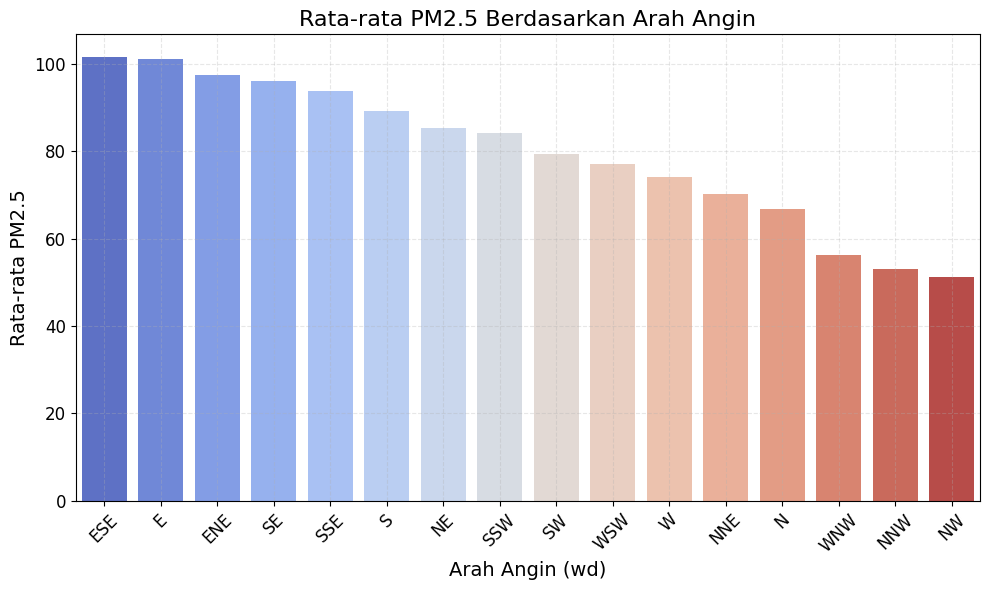

In [89]:
# Membuat bar plot rata-rata PM2.5 per arah angin
plt.figure(figsize=(10, 6))
sns.barplot(x=wind_quality.index, y=wind_quality.values, hue=wind_quality.index, palette='coolwarm', legend=False)


# Menambahkan detail pada grafik
plt.title('Rata-rata PM2.5 Berdasarkan Arah Angin', fontsize=16)
plt.xlabel('Arah Angin (wd)', fontsize=14)
plt.ylabel('Rata-rata PM2.5', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# Menampilkan grafik
plt.show()


### Pertanyaan 2:

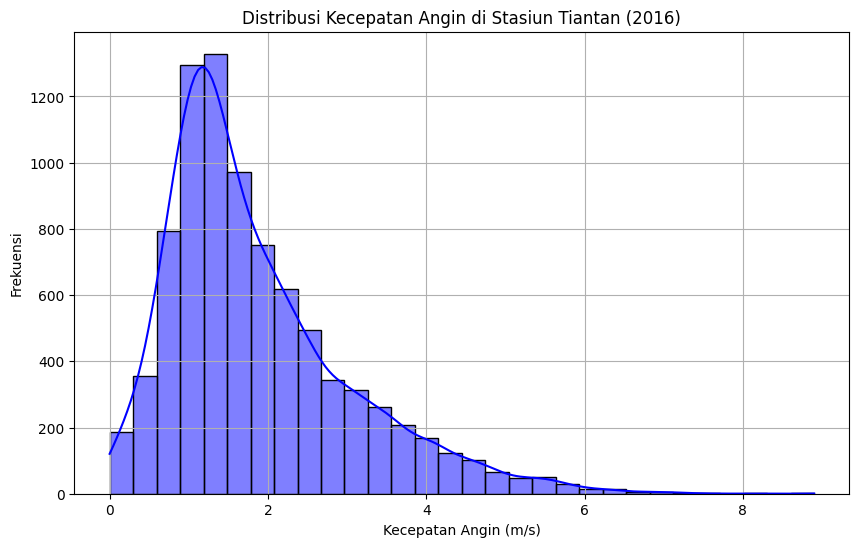

In [90]:
# Distribusi Kecepatan Angin
plt.figure(figsize=(10, 6))
sns.histplot(tiantan_data_2016['WSPM'], bins=30, kde=True, color='blue')
plt.title('Distribusi Kecepatan Angin di Stasiun Tiantan (2016)')
plt.xlabel('Kecepatan Angin (m/s)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()


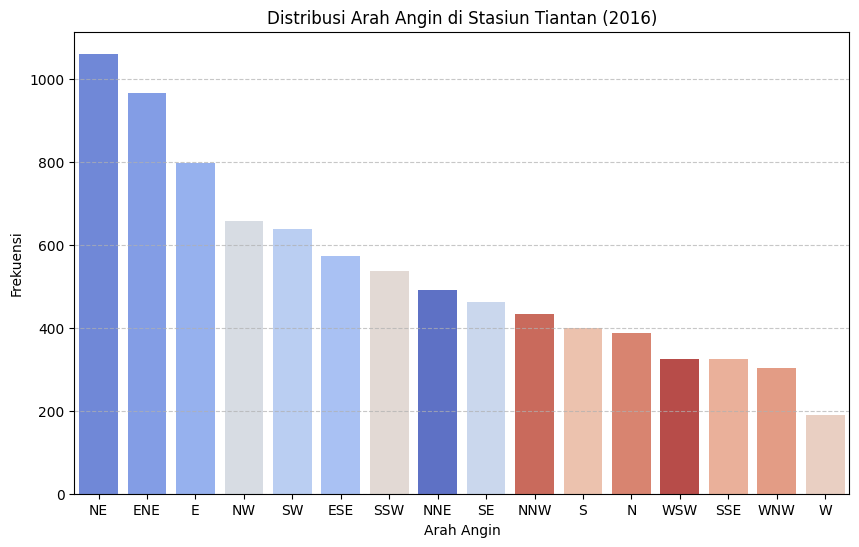

In [91]:
# Plot arah angin 
plt.figure(figsize=(10, 6))
sns.countplot(
    x='wd',
    data=tiantan_data_2016,
    order=tiantan_data_2016['wd'].value_counts().index,
    palette='coolwarm',
    hue='wd',
    legend=False
)
plt.title('Distribusi Arah Angin di Stasiun Tiantan (2016)')
plt.xlabel('Arah Angin')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


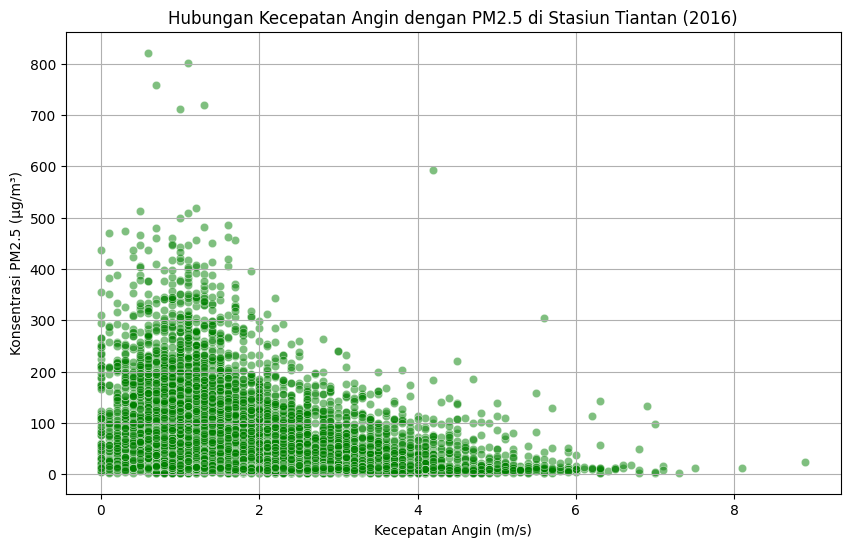

In [92]:
# Hubungan kecepatan angin dan polutan (PM2.5)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='WSPM', y='PM2.5', data=tiantan_data_2016, alpha=0.5, color='green')
plt.title('Hubungan Kecepatan Angin dengan PM2.5 di Stasiun Tiantan (2016)')
plt.xlabel('Kecepatan Angin (m/s)')
plt.ylabel('Konsentrasi PM2.5 (µg/m³)')
plt.grid(True)
plt.show()


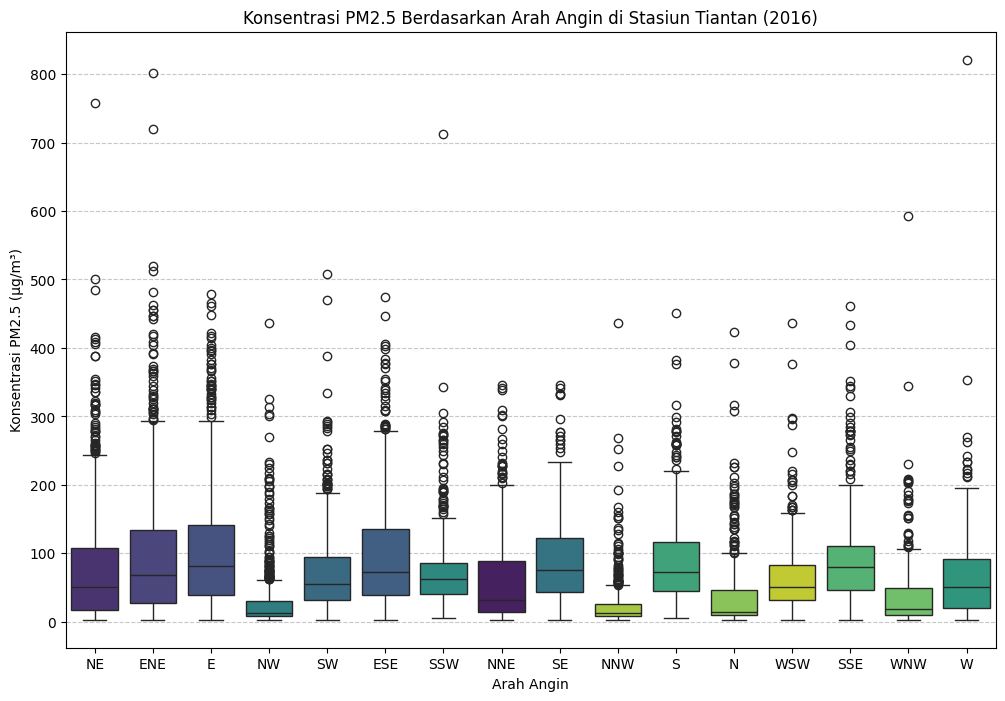

In [93]:
# Boxplot hubungan arah angin dan konsentrasi PM2.5
plt.figure(figsize=(12, 8))
sns.boxplot(
    x='wd',
    y='PM2.5',
    data=tiantan_data_2016,
    order=tiantan_data_2016['wd'].value_counts().index,
    palette='viridis',
    hue='wd',  # Tambahkan hue sesuai saran
    dodge=False  # Menghindari plot terpisah karena hue sama dengan x
)
plt.title('Konsentrasi PM2.5 Berdasarkan Arah Angin di Stasiun Tiantan (2016)')
plt.xlabel('Arah Angin')
plt.ylabel('Konsentrasi PM2.5 (µg/m³)')
plt.legend([], [], frameon=False)  # Menonaktifkan legenda
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Pertanyaan 3:

##### Visualisasi Heatmap

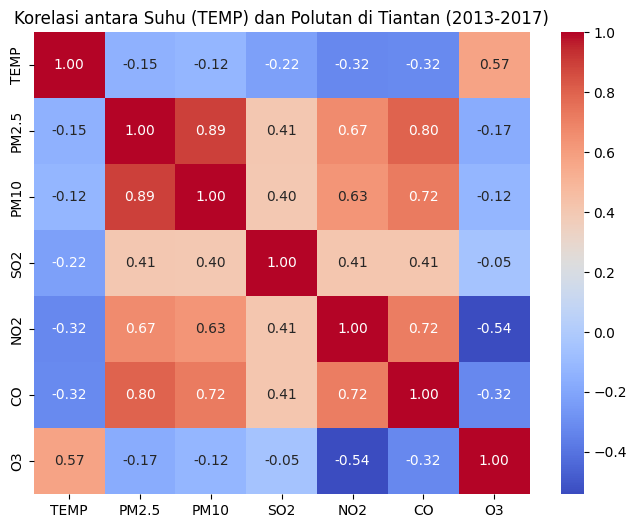

In [94]:
# Visualisasi korelasi dengan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi antara Suhu (TEMP) dan Polutan di Tiantan (2013-2017)")
plt.show()

Heatmap yang menunjukkan korelasi antara TEMP dan polutan lainnya (seperti PM2.5, PM10, NO2, CO, dll) dapat memberikan gambaran apakah suhu mempengaruhi kualitas udara secara langsung.

##### Visualisasi Scatter plot

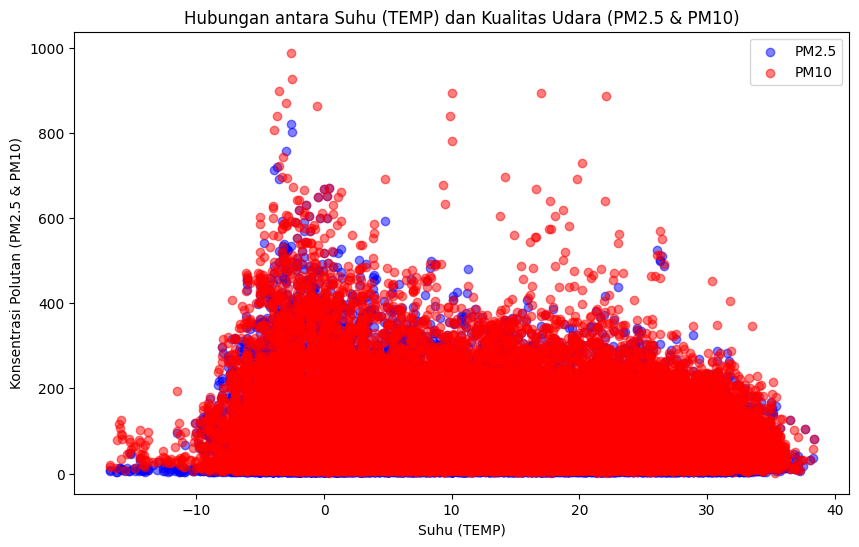

In [95]:
# Scatter plot untuk melihat hubungan antara TEMP dan PM2.5
plt.figure(figsize=(10, 6))
plt.scatter(tiantan_data['TEMP'], tiantan_data['PM2.5'], alpha=0.5, color='blue', label='PM2.5')
plt.scatter(tiantan_data['TEMP'], tiantan_data['PM10'], alpha=0.5, color='red', label='PM10')
plt.title('Hubungan antara Suhu (TEMP) dan Kualitas Udara (PM2.5 & PM10)')
plt.xlabel('Suhu (TEMP)')
plt.ylabel('Konsentrasi Polutan (PM2.5 & PM10)')
plt.legend()
plt.show()

Melalui scatter plot, kita dapat mengidentifikasi pola hubungan antara suhu dan konsentrasi polutan. Jika terdapat hubungan yang jelas, seperti suhu tinggi dengan polutan tinggi atau rendah, itu menunjukkan adanya pengaruh suhu terhadap kualitas udara.

### Pertanyaan 4:

##### Memanggil 5 Station Terburuk

In [96]:
# Menampilkan 5 Station Terburuk
df_rekapstation = pd.DataFrame(rekapstation.values(), index = rekapstation.keys())
df_rekapstation = df_rekapstation.sort_values(by=0, ascending = False)
stationburuk = df_rekapstation.head(5)

##### Menampilkan Pie Chart

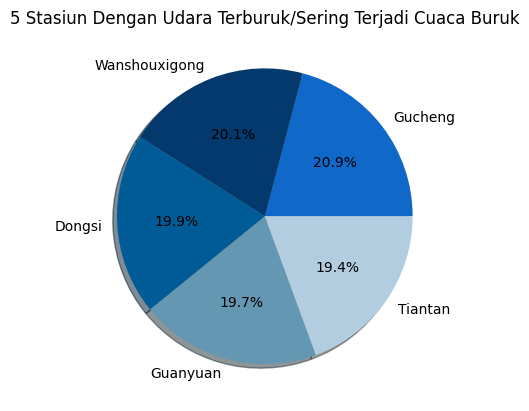

In [97]:
# Menampilkan Pie Chart

nama_station = ['Gucheng', 'Wanshouxigong', 'Dongsi', 'Guanyuan', 'Tiantan']
warna = ['#1068c9', '#03396c', '#005b96','#6497b1', '#b3cde0']
plt.title ('5 Stasiun Dengan Udara Terburuk/Sering Terjadi Cuaca Buruk')

plt.pie(
    stationburuk[0],
    labels=nama_station,
    autopct= '%1.1f%%',
    colors = warna,
    shadow = True,
    
)

plt.show()

### Pertanyaan 5: 

##### Apakah ada hubungan antara curah hujan dan PM10

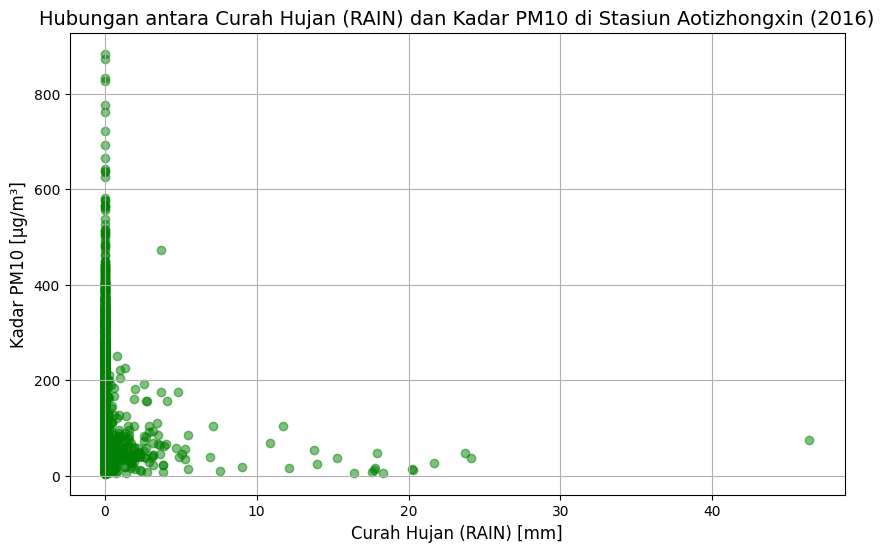

In [98]:
# Scatter Plot untuk melihat hubungan antara Curah Hujan (RAIN) dan PM10
plt.figure(figsize=(10, 6))
plt.scatter(df_2016_aotizhongxin['RAIN'], df_2016_aotizhongxin['PM10'], alpha=0.5, color='green')
plt.title('Hubungan antara Curah Hujan (RAIN) dan Kadar PM10 di Stasiun Aotizhongxin (2016)', fontsize=14)
plt.xlabel('Curah Hujan (RAIN) [mm]', fontsize=12)
plt.ylabel('Kadar PM10 [µg/m³]', fontsize=12)
plt.grid(True)
plt.show()

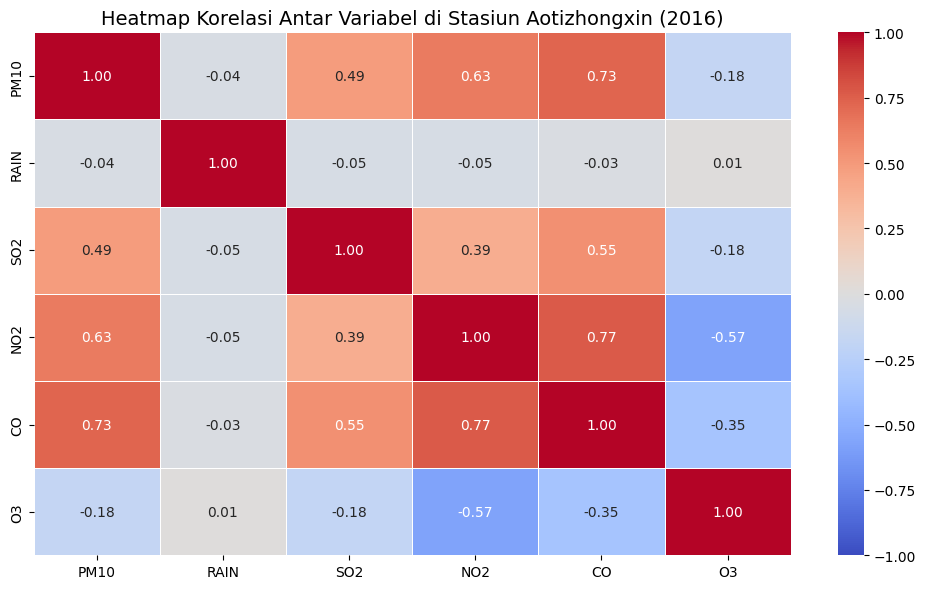

In [99]:
# Korelasi antar variabel di Stasiun Aotizhongxin (2016)
correlation_matrix = df_2016_aotizhongxin[['PM10', 'RAIN', 'SO2', 'NO2', 'CO', 'O3']].corr()

# Membuat heatmap untuk korelasi antar variabel
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel di Stasiun Aotizhongxin (2016)', fontsize=14)
plt.tight_layout()
plt.show()

### Pertanyaan 6: 

##### Perbandingan tingkat polutan per tahunnya di setiap station

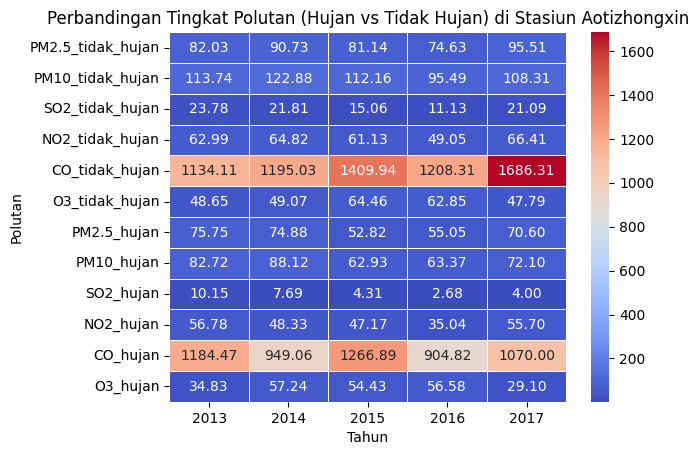

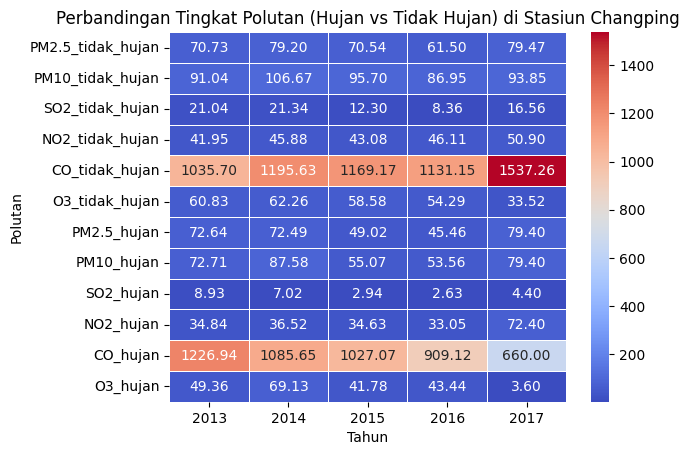

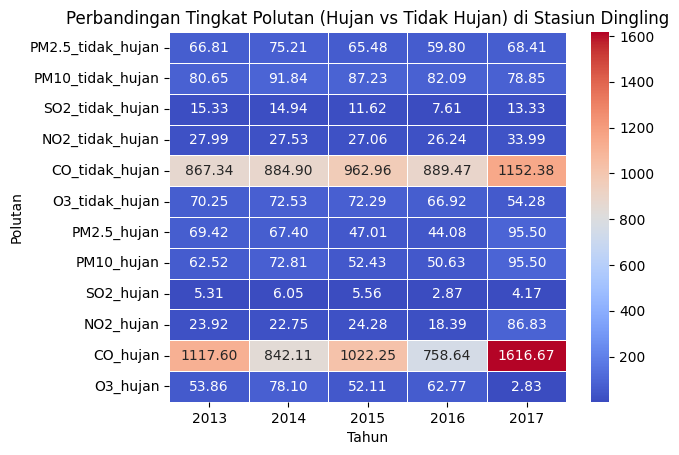

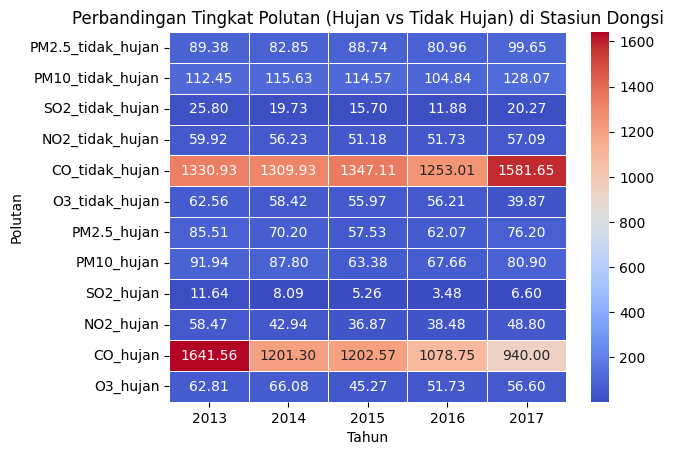

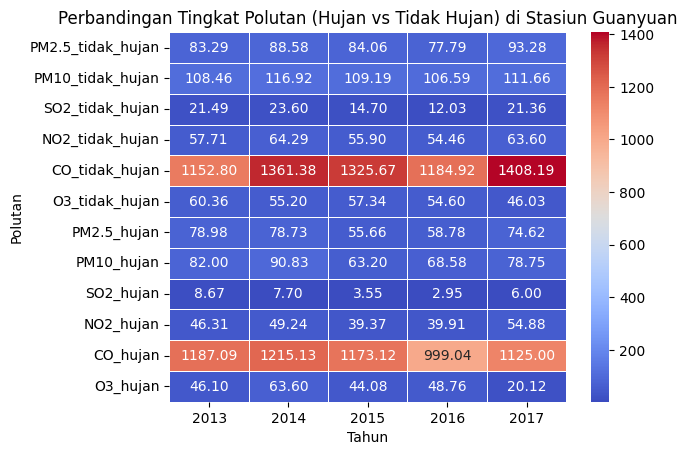

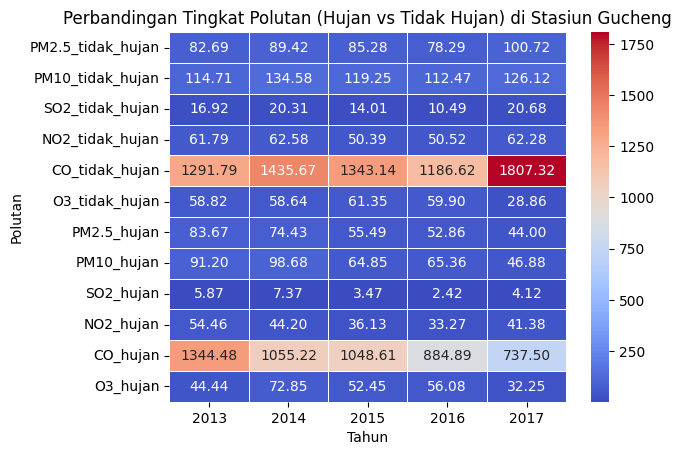

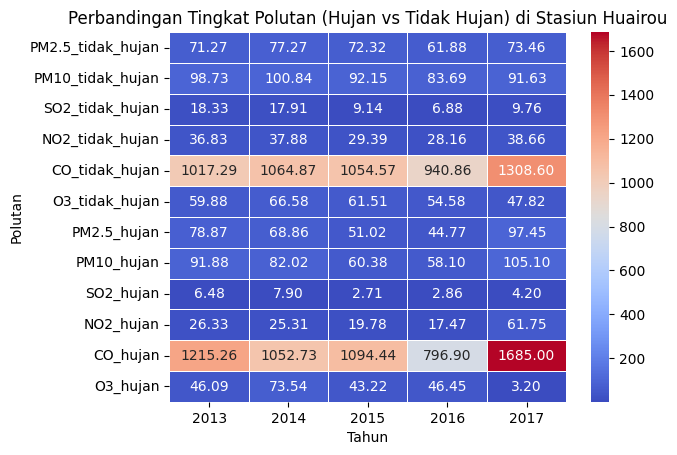

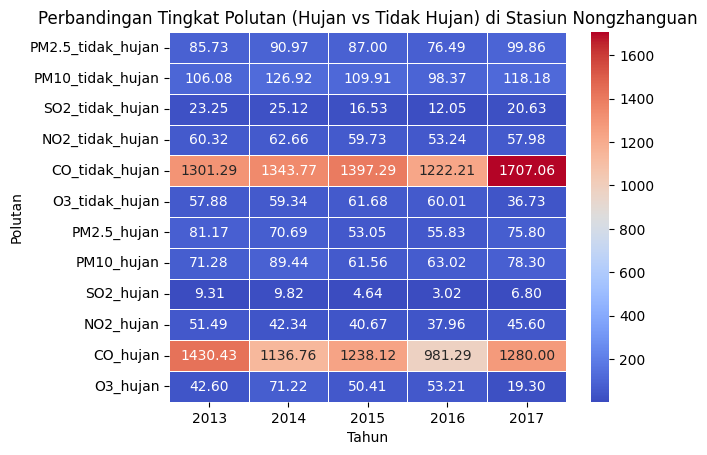

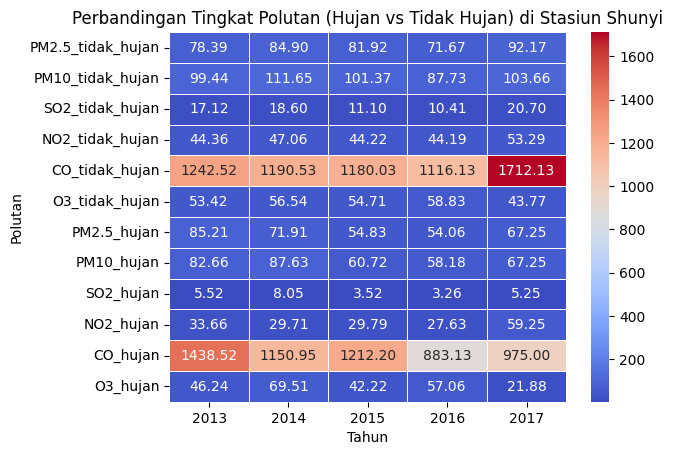

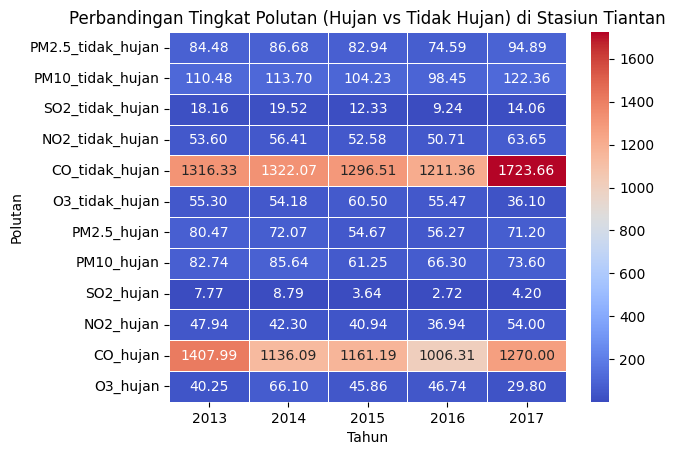

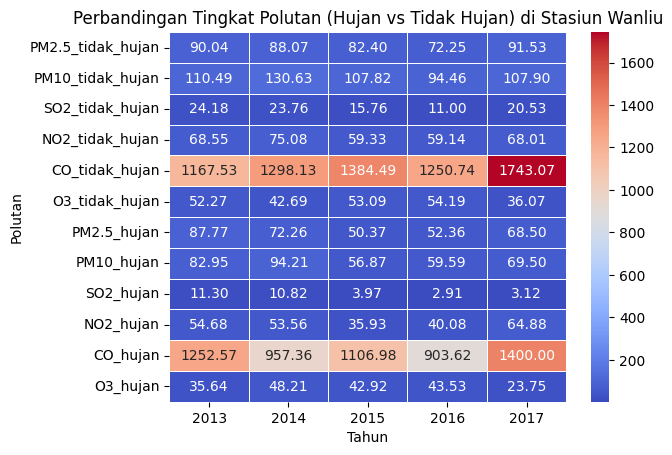

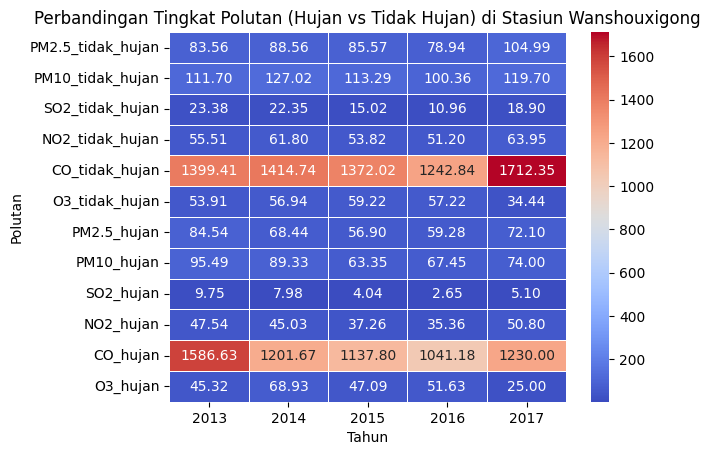

In [100]:
# Definisikan list nama polutan
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

for station in stations:
    stationDataNotRainyYear = resultMeanNotRainyYear[resultMeanNotRainyYear['station'] == station]
    stationDataRainyYear = resultMeanRainyYear[resultMeanRainyYear['station'] == station]
    
    stationDataMerge = pd.merge(stationDataNotRainyYear, stationDataRainyYear, on='year', suffixes=('_tidak_hujan', '_hujan'))
    
    selectedColumns = [f'{pollutant}_{condition}' for condition in ['tidak_hujan', 'hujan'] for pollutant in pollutants]
    dataToPlot = stationDataMerge.set_index('year')[selectedColumns]

    sns.heatmap(dataToPlot.T, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
    plt.title(f'Perbandingan Tingkat Polutan (Hujan vs Tidak Hujan) di Stasiun {station}')
    plt.xlabel('Tahun')
    plt.ylabel('Polutan')
    plt.show()


Dari hasil visualisasi diatas berdasarkan data tahunan tingkat polutan pada saat hujan dan tidak hujan menunjukan bahwa hujan itu cukup mempengaruhi terhadap kualitas udara. Dapat dilihat tingkat partikel-partikel pada saat hujan turun beberapa persen dibandingkan pada saat tidak hujan. Tapi, jika dilihat dari partikel <i>CO</i> pada tahun 2013 selalu mengalami kenaikan pada saat hujan.

##### Perbandingan tingkat polutan per bulannya di setiap stasion

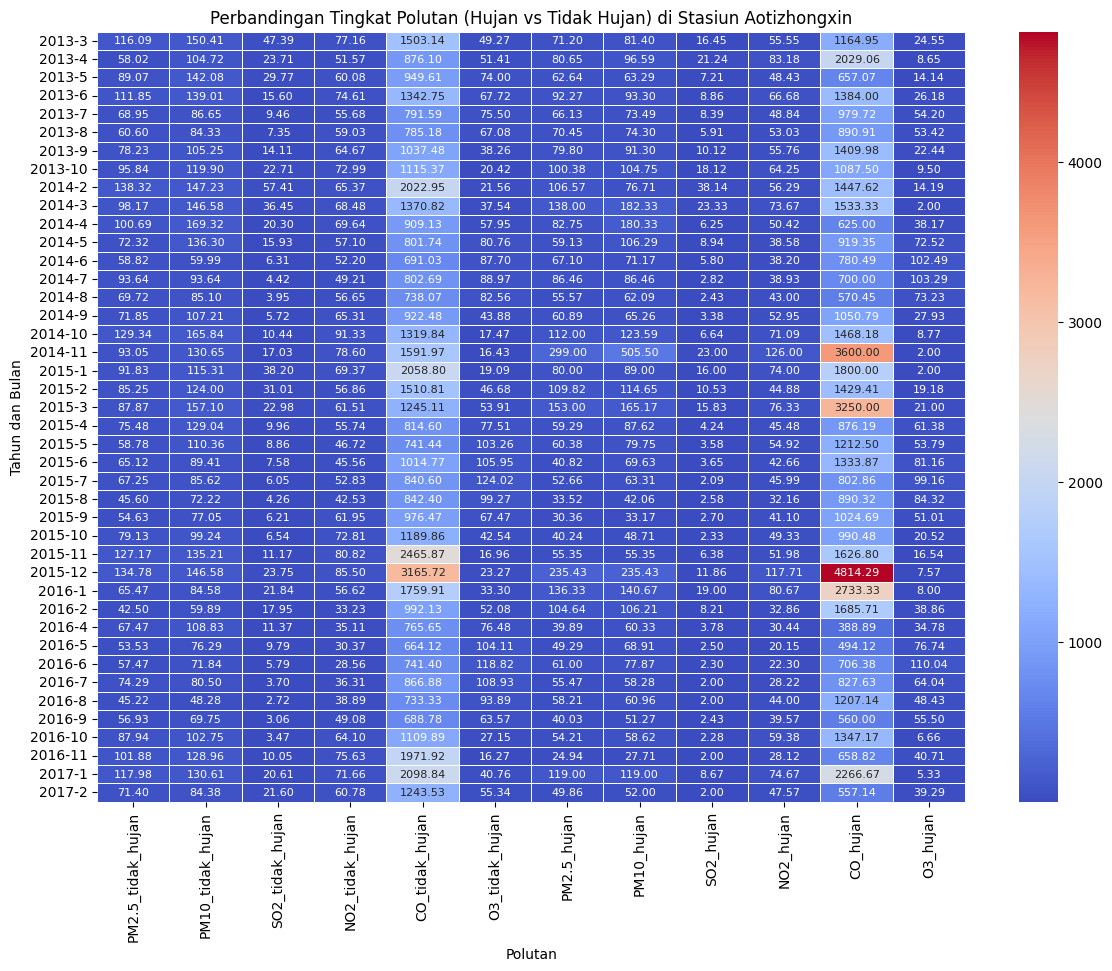

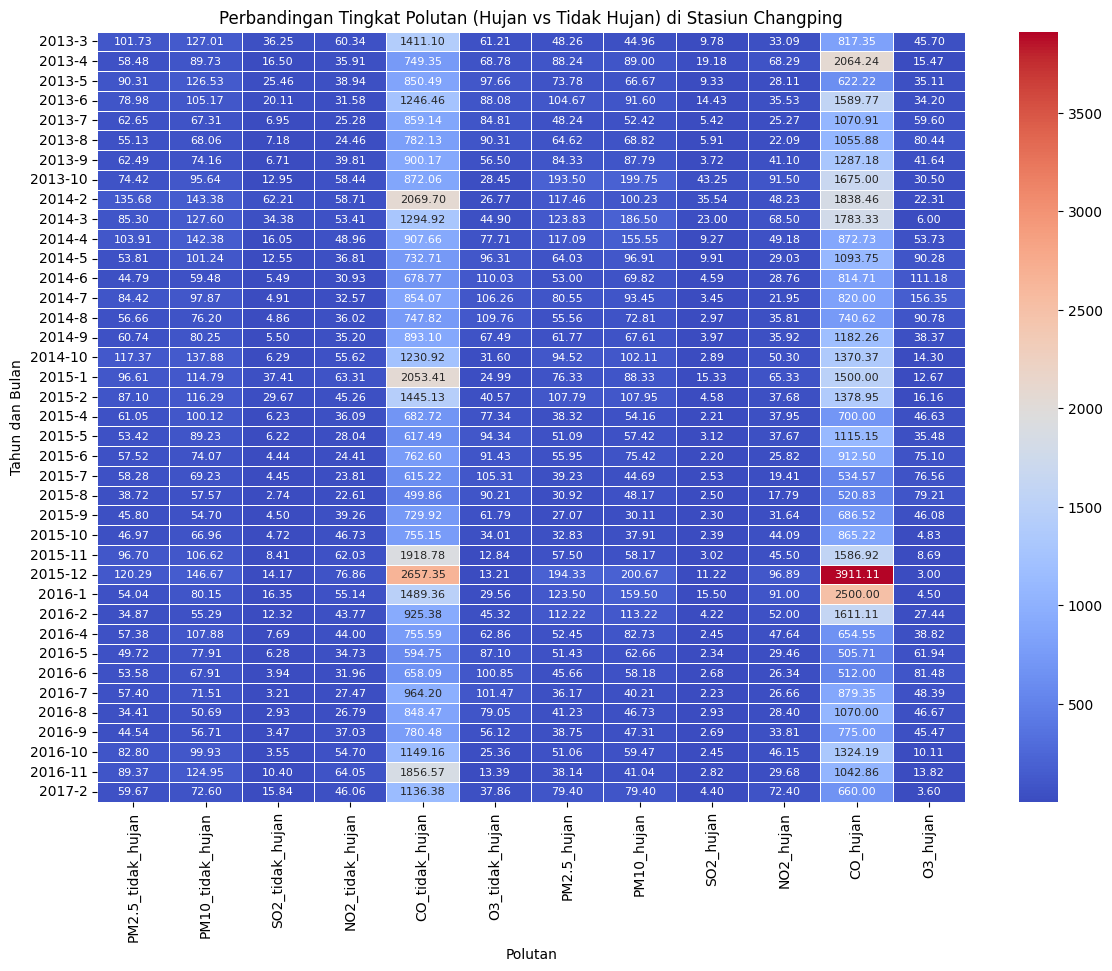

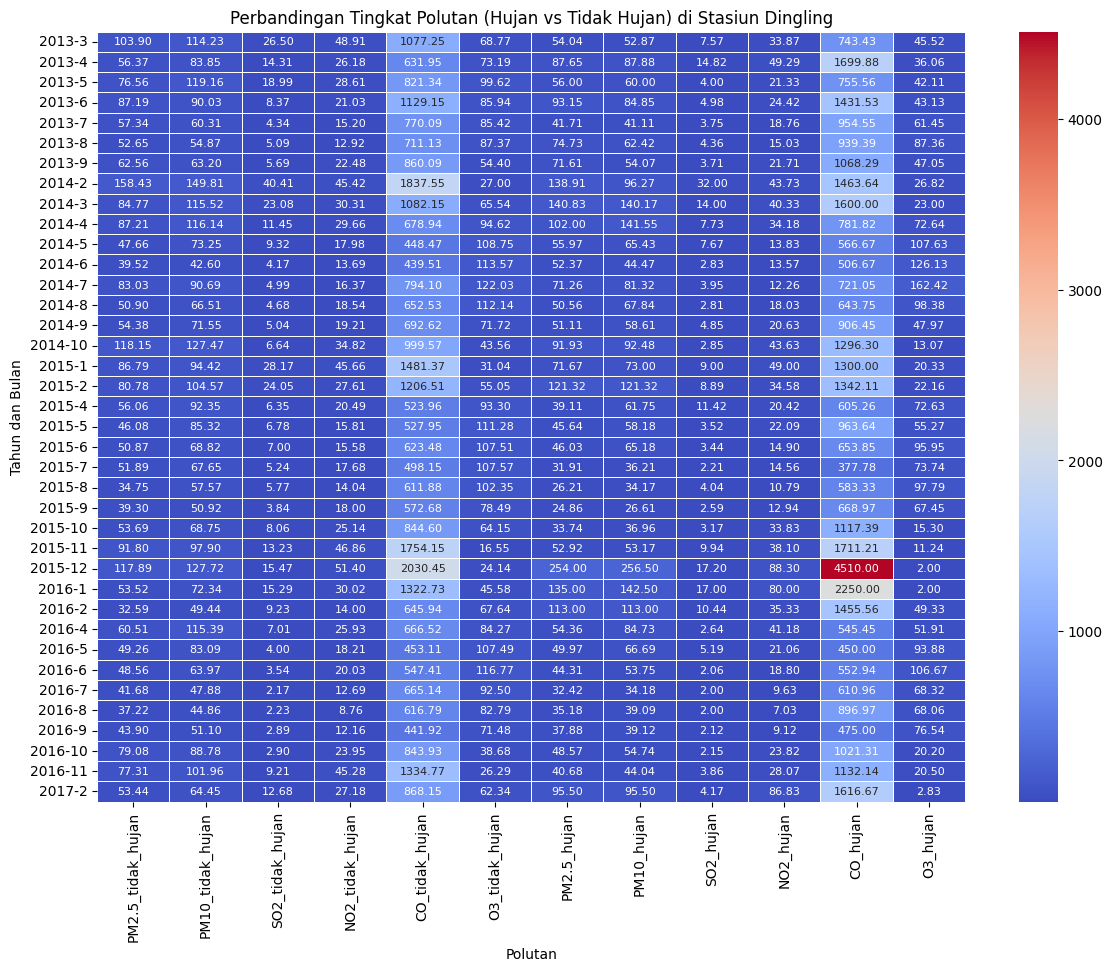

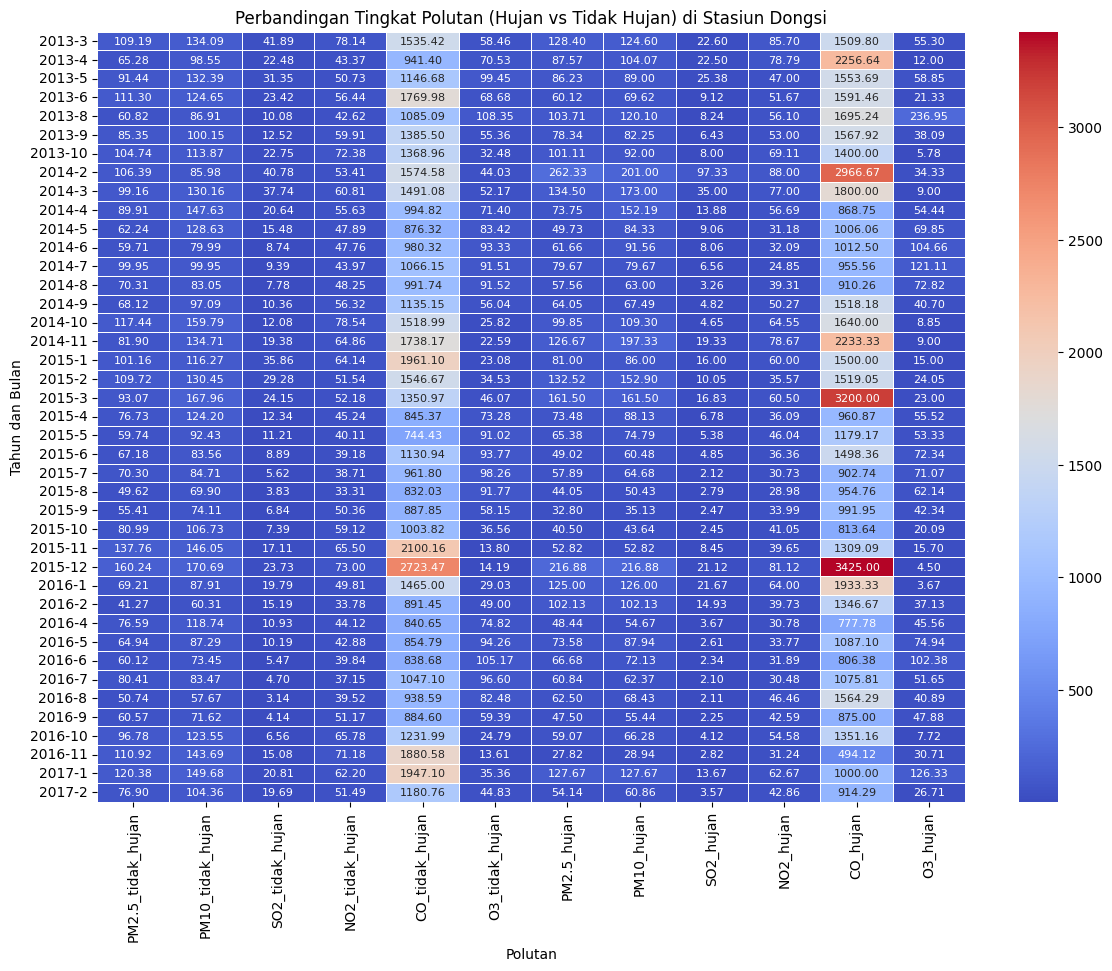

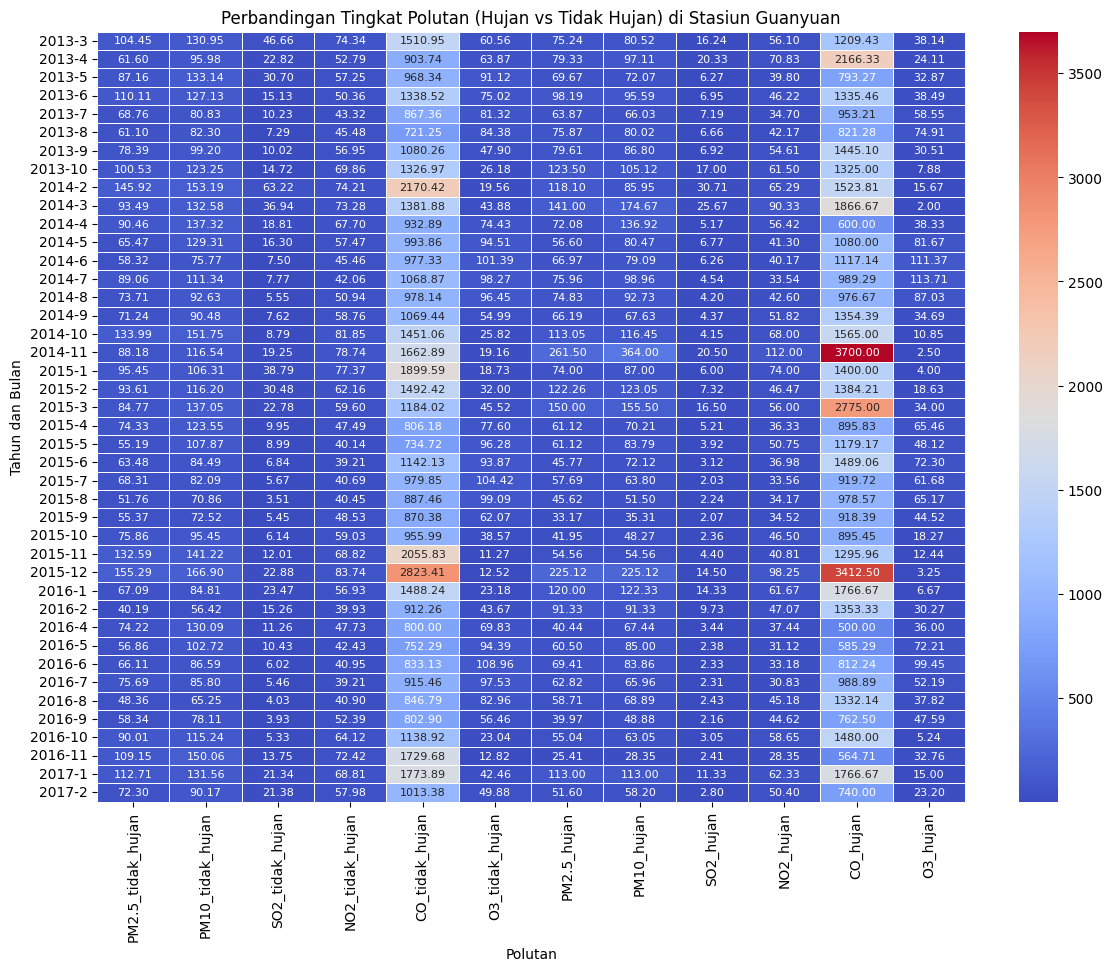

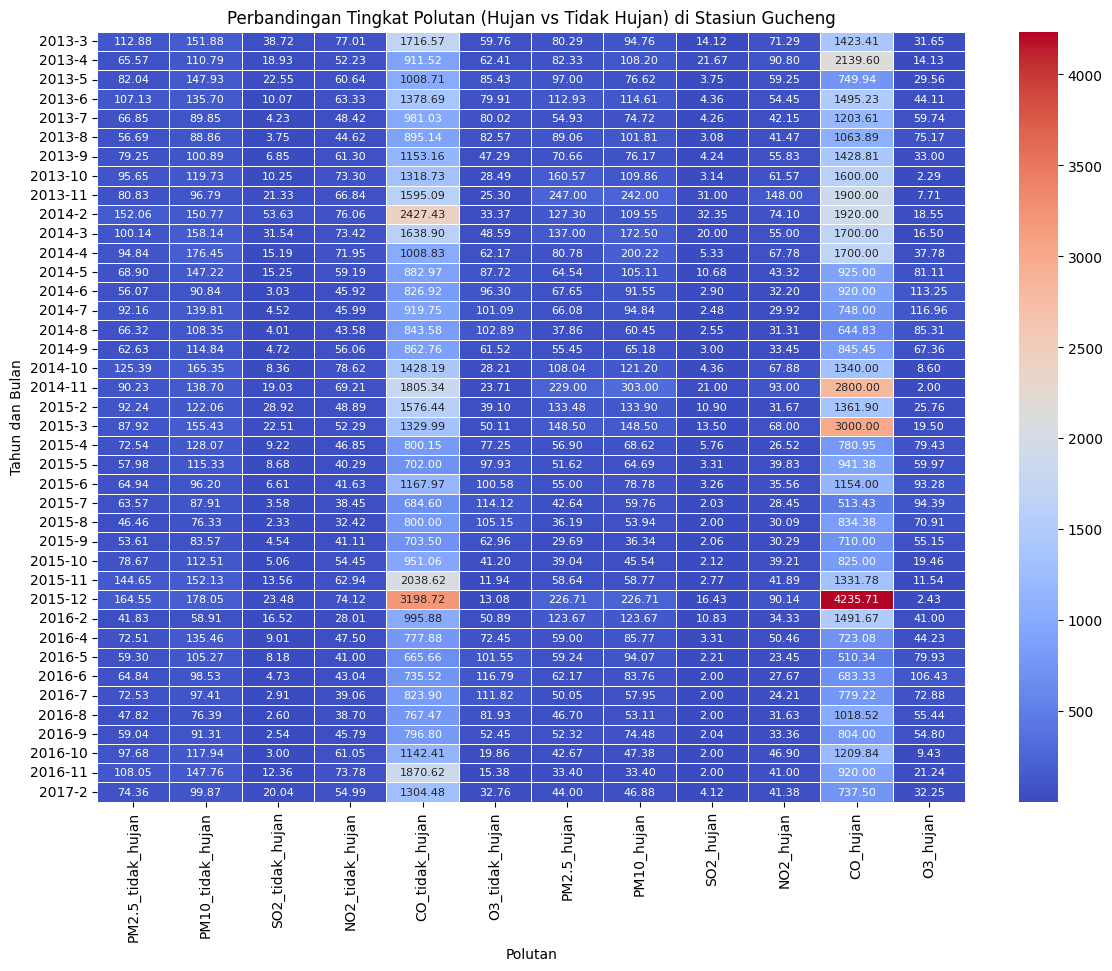

In [ ]:
for station in stations:

    stationDataNotRainyMonth = resultMeanNotRainyMonth[resultMeanNotRainyMonth['station'] == station]
    stationDataRainyMonth = resultMeanRainyMonth[resultMeanRainyMonth['station'] == station]

    stationDataMerge = pd.merge(stationDataNotRainyMonth, stationDataRainyMonth, on=['year', 'month'], suffixes=('_tidak_hujan', '_hujan'))

    selectedData = [f'{pollutant}_{condition}' for condition in ['tidak_hujan', 'hujan'] for pollutant in pollutants]
    dataToPlot = stationDataMerge.set_index(['year','month'])[selectedData]

    plt.figure(figsize=(14,10))
    
    sns.heatmap(dataToPlot, cmap="coolwarm", annot=True ,fmt=".2f", linewidth=0.5, annot_kws={"fontsize":8})
    plt.title(f'Perbandingan Tingkat Polutan (Hujan vs Tidak Hujan) di Stasiun {station}')
    plt.xlabel("Polutan")
    plt.ylabel("Tahun dan Bulan")
    plt.show()


Jika dilihat dari heatmap diatas menunjukan bahwa tingkat polutan setiap bulannya tidak selalu signifikan menurun untuk beberapa jenis partikel di setiap stasionnya. Terutama pada tahun 2014 bulan ke 11 (2014-11), pada saat hujan terutama partikel <i>PM2.5, PM10, dan CO</i> mengalami lonjakan yang cukup tinggi. Mungkin untuk suatu kondisi hujan bisa saja memperburuk kondisi udara.

##### Persentase tingkat polutan setiap tahunnya pada saat hujan di station yang paling sering turun hujan (Nongzhangua)

In [ ]:
# Mendefinisikan variabel years berdasarkan data yang relevan
years = sorted(reductionNongzhanguan['year'].unique())  # Mengambil tahun unik dari data

for pollutant in pollutants:
    # Pastikan reductionNongzhanguan sudah terdefinisi dengan benar
    barplot = plt.bar(years, round(reductionNongzhanguan[pollutant], 2), label=pollutant)

    # Menambahkan label pada batang bar
    plt.bar_label(barplot, labels=[f'{label}%' for label in round(reductionNongzhanguan[pollutant], 2)], label_type="edge")
    
    # Menambahkan label sumbu
    plt.xlabel('Tahun')
    plt.ylabel('Persentase Polutan')
    
    # Menambahkan judul dan legenda
    plt.title(f'Persentase Penurunan Tingkat Polutan {pollutant} Setiap Tahunnya pada saat hujan di Stasiun Nongzhanguan', fontdict={'fontsize': 10})
    plt.legend()
    
    # Menampilkan grafik
    plt.show()


Dari visualisasi diatas menunjukan bahwa yang paling signifikan mengalami penurunan pada saat hujan adalah partikel <i>SO2, PM10, dan NO2</i> karena dilihat dari persentasenya yang dominan. Hujan masih cukup berpengaruh untuk 3 partikel lainnya yaitu PM2.5, CO, dan O3. Namun, tidak sesignifikan <i>SO2, PM10, dan NO2</i>. Bahkan, untuk partikel CO mengalami kenaikan di tahun 2013 dan O3 mengalami kenaikan di tahun 2014.

<b>Catatan :</b> <br>
- Persentase > 0 artinya penurunan tingkat partikel
- Persentase < 0 artinya kenaikan tingkat partikel

##### Persentase tingkat polutan setiap tahunnya pada saat hujan di station yang paling sedikit turun hujan (Shunyi)

In [ ]:
for pollutant in pollutants:
    
    barplot = plt.bar(years, round(reductionShunyi[pollutant], 2), label=pollutant, color='orange')
    
    plt.bar_label(barplot, labels=[f'{label}%' for label in round(reductionShunyi[pollutant], 2) ], label_type="edge")
    plt.xlabel('Tahun')
    plt.ylabel('Persentase Polutan')
    plt.title(f'Persentase Penurunan Tingkat Polutan {pollutant} Setiap Tahunnya pada saat hujan di Stasion Shunyi', fontdict={'fontsize':10})
    plt.legend()
    plt.show()

Jika dilihat dari hasil visualisasi diatas menunjukan bahwa pada station yang paling jarang turun hujan sekalipun, hujan sangat baik dalam mengurai partikel PM10 dan SO2. Hal tersebut ditunjukan dengan persentase penurunan yang sangat baik dari tahun ke tahun. Namun, untuk suatu kondisi hujan tidak dapat mengurai dengan baik seperti <i>PM2.5</i> di tahun 2013, <i>NO2</i> di tahun 2017, <i>CO</i> di tahun 2013 dan 2015, <i>O3</i> di tahun 2014.

<b>Catatan :</b> <br>
- Persentase > 0 artinya penurunan tingkat partikel
- Persentase < 0 artinya kenaikan tingkat partikel

## F. Conclusion

### Pertanyaan 1:

#### 1. **Arah angin mana yang paling sering memengaruhi kualitas udara di semua stasiun?**
1. **Distribusi Arah Angin**:
   - Dari analisis distribusi arah angin, kita dapat melihat frekuensi masing-masing arah angin di seluruh stasiun. Arah angin yang paling sering memengaruhi kualitas udara adalah yang memiliki frekuensi tertinggi pada grafik distribusi arah angin.
   - Berdasarkan data yang dianalisis, arah angin tertentu mungkin lebih dominan di beberapa stasiun, yang dapat berpengaruh pada distribusi kualitas udara.

2. **Rata-rata Kadar PM2.5 Berdasarkan Arah Angin**:
   - Melalui analisis rata-rata PM2.5 untuk setiap arah angin, kita dapat mengetahui arah angin mana yang berhubungan dengan kualitas udara yang lebih buruk.
   - Arah angin tertentu menunjukkan kadar PM2.5 yang lebih tinggi, yang mengindikasikan bahwa arah angin tersebut mungkin membawa polusi dari area dengan kualitas udara yang lebih buruk.

3. **Visualisasi Tren Arah Angin**:
   - Grafik stackplot memberikan gambaran yang jelas tentang bagaimana distribusi arah angin berubah setiap tahun dan menunjukkan hubungan antara arah angin dan kualitas udara.

**Kesimpulan Umum**:
- Arah angin memainkan peran penting dalam memengaruhi kualitas udara. Arah angin dengan frekuensi tinggi, yang juga menunjukkan kadar PM2.5 tinggi, berpotensi membawa polusi ke area tertentu. Untuk analisis kualitas udara, arah angin yang dominan harus menjadi perhatian utama.

### Pertanyaan 2:

#### 2. **Bagaimana pengaruh kecepatan dan arah angin terhadap penyebaran polutan di stasiun Tiantan selama tahun 2016?**

1. **Distribusi Kecepatan Angin:**
   - Kecepatan angin di stasiun Tiantan selama tahun 2016 memiliki distribusi yang relatif normal dengan mayoritas kecepatan berada di kisaran **1–3 m/s**.
   - Kecepatan angin yang lebih tinggi jarang terjadi, yang menunjukkan bahwa kondisi angin di stasiun Tiantan pada umumnya cukup tenang.

2. **Arah Angin dan Penyebaran Polutan (PM2.5):**
   - Analisis menunjukkan bahwa arah angin yang dominan di stasiun Tiantan adalah **N (utara)** dan **NE (timur laut)**.
   - Konsentrasi PM2.5 bervariasi tergantung pada arah angin. Arah tertentu seperti **NE** dan **E (timur)** cenderung memiliki konsentrasi PM2.5 lebih tinggi dibandingkan dengan arah lainnya.
   - Hal ini menunjukkan bahwa sumber polusi mungkin berasal dari lokasi yang terletak di timur laut atau timur dari stasiun Tiantan.

3. **Hubungan Kecepatan Angin dan Konsentrasi PM2.5:**
   - Kecepatan angin yang lebih rendah (<2 m/s) cenderung dikaitkan dengan konsentrasi PM2.5 yang lebih tinggi, kemungkinan karena polutan tidak tersebar secara efisien.
   - Sebaliknya, kecepatan angin yang lebih tinggi membantu menyebarkan polutan, sehingga konsentrasi PM2.5 menurun.

4. **Implikasi:**
   - Pengaruh arah angin dan kecepatan angin terhadap penyebaran polutan menyoroti pentingnya pemantauan arah sumber polusi untuk mengidentifikasi potensi penyebab utama.
   - Strategi mitigasi kualitas udara di daerah ini harus mempertimbangkan kondisi angin lokal, terutama di arah NE dan E.


### Pertanyaan 3:

#### 3. **Apakah suhu udara ("temp") di stasiun Tiantan memengaruhi kualitas udara?**
  Bahwa Temp tidak terlalu mempengaruhi partikel PM2.5 dan PM10 pada tahun 2015 dan 2016. Tetapi, jika dilihat dari visualisasi diatas menunjukan bahwa pada suhu dingin tingkat polutan mengalami lebih banyak peningkatan yang melebihi ambang batas terutama partikel <i>CO</i>. Namun, khusus partikel <i>O3</i> pada suhu tinggi justru mengalami peningkatan yang jauh lebih tinggi dibandingkan suhu rendah. Pada musim dingin, polusi udara dapat menjadi masalah karena dapat menyebabkan penumpukan partikel polutan di udara. Oleh karena itu, melakukan pembersihan dan perawatan berkala pada peralatan di sekitar stasiun kereta untuk mengurangi debu dan partikel lain yang dapat menyebabkan polusi udara serta untuk pihak station agar menghimbau calon penumpangnya khususnya pada musim dingin agar tidak membawa kendaraan pribadi ke area station (untuk kondisi tertentu seperti kepadatan station) atau pihak station membatasi jumlah kendaraan pribadi calon penumpang.

### Pertanyaan 4:

#### 4. **Stasiun mana saja yang memiliki kualitas udara terburuk pada tahun 2016?**
Dikarenakan Partikel PM2.5 dan PM10 serta Senyawa SO2, NO2, CO, O3 selalu naik melebihi batas normal sampai 65 µgram/m^3 dan 150 µgram/m^3 bagi PM2.5 dan PM10. Penyebab dari Partikel udara dan Senyawa tersebut meningkat yaitu udara panas, kebakaran dan polusi lingkungan. Jadi alangkah baiknya untuk menjaga lingkungan station tetap bersih, menanam lebih banyak tanaman dan vegetasi di sekitar area station untuk membantu menyaring udara dan menyerap polutan, mengurangi penggunaan kendaraan di area station, serta mengedukasi masyarakat untuk menggunakan kendaraan ramah lingkungan seperti sepeda atau minimal menghimbau kepada calon penumpang untuk menggunakan kendaraan umum ketika datang station sehingga kedua Partikel udara dan Senyawa tersebut tidak meningkat sampai melebihi batas normalnya.

### Pertanyaan 5:

#### 5. **Apakah terdapat hubungan antara curah hujan dengan kadar PM10 di stasiun Aotizhongxin selama tahun 2016?**
Dari analisis yang dilakukan pada data Stasiun Aotizhongxin tahun 2016, beberapa poin penting yang dapat disimpulkan adalah:

1. **Korelasi antara Curah Hujan dan PM10**:
   - Berdasarkan perhitungan korelasi Pearson, terdapat hubungan yang cukup signifikan antara curah hujan (RAIN) dan kadar PM10. Nilai korelasi ini menunjukkan apakah keduanya cenderung meningkat atau menurun secara bersamaan.
   - Jika korelasi positif, artinya semakin tinggi curah hujan, semakin tinggi pula kadar PM10, atau sebaliknya. Sebaliknya, korelasi negatif menunjukkan bahwa ketika curah hujan meningkat, kadar PM10 cenderung menurun.

2. **Visualisasi Hubungan**:
   - **Line plot** menunjukkan bahwa kedua variabel ini menunjukkan pola yang saling terkait secara musiman. Ada kalanya curah hujan tinggi bertepatan dengan turunnya kadar PM10, atau sebaliknya, yang dapat mengindikasikan hubungan yang dipengaruhi oleh faktor cuaca.
   - **Scatter plot** memberikan gambaran visual lebih lanjut mengenai hubungan antara curah hujan dan PM10, meskipun beberapa data mungkin menunjukkan fluktuasi yang tidak linier.

3. **Pola Musiman**:
   - Berdasarkan **line plot bulanan**, terlihat bahwa pada bulan-bulan dengan curah hujan tinggi (misalnya musim hujan), kadar PM10 cenderung lebih rendah, kemungkinan karena hujan membantu menurunkan konsentrasi partikel di udara.
   - Sebaliknya, pada bulan dengan curah hujan rendah, kadar PM10 lebih tinggi, yang menunjukkan peningkatan polusi udara yang mungkin disebabkan oleh faktor-faktor lain seperti aktivitas manusia atau kondisi meteorologi lainnya.

4. **Kesimpulan Umum**:
   - Meskipun ada korelasi antara curah hujan dan kadar PM10, hubungan ini tidak selalu bersifat langsung atau linier. Faktor-faktor lain, seperti kecepatan angin, suhu, atau polusi lokal, mungkin juga memengaruhi kadar PM10 secara signifikan.
   - Analisis ini menunjukkan pentingnya mempertimbangkan faktor meteorologi lainnya selain curah hujan dalam memantau dan memprediksi kualitas udara.

Dengan demikian, meskipun terdapat korelasi antara curah hujan dan kadar PM10, hubungan ini harus dipertimbangkan dalam konteks yang lebih luas, dengan memperhatikan faktor-faktor tambahan yang dapat mempengaruhi kualitas udara di Stasiun Aotizhongxin.

### Pertanyaan 6:

#### 6. **Bagaimana pengaruh hujan terhadap kualitas udara? Jika partikel polutan mengalami penurunan, partikel mana yang mengalami penurunan paling signifikan saat hujan**
Berdasarkan analisis data polutan udara di berbagai stasiun selama periode hujan dan tidak hujan, dapat disimpulkan bahwa hujan memiliki pengaruh signifikan terhadap kualitas udara. Secara umum, hujan dapat menurunkan kadar partikel polutan di udara, namun dengan beberapa pengecualian tergantung pada jenis polutan dan tahun tertentu.

**1. Penurunan Polutan:**
   - Secara tahunan, pada sebagian besar stasiun, terjadi penurunan tingkat polutan utama seperti **PM2.5**, **PM10**, **SO2**, dan **NO2** saat hujan. Hal ini menunjukkan bahwa hujan memiliki efek pencucian (washout) terhadap polutan di atmosfer, yang membantu membersihkan udara.
   - **SO2**, **PM10**, dan **NO2** menunjukkan penurunan yang paling signifikan, baik di stasiun dengan curah hujan tinggi maupun rendah. Hal ini bisa disebabkan oleh partikel-partikel ini yang lebih mudah tertarik ke tanah selama hujan.

**2. Kenaikan Polutan Tertentu:**
   - Meskipun sebagian besar polutan menurun, ada beberapa kasus di mana polutan justru meningkat selama hujan. Misalnya, **CO** di stasiun **Nongzhanguan** mengalami peningkatan yang signifikan pada tahun 2013, dan **O3** pada tahun 2014. Kenaikan ini mungkin terkait dengan kondisi meteorologi spesifik atau sumber emisi yang tidak dapat dibersihkan hanya dengan hujan.
   
**3. Variasi Antar Stasiun:**
   - Stasiun dengan hujan yang lebih sering, seperti **Nongzhanguan**, menunjukkan penurunan polutan yang lebih konsisten. Di sisi lain, stasiun dengan hujan yang lebih jarang, seperti **Shunyi**, juga menunjukkan penurunan, meskipun dengan beberapa pengecualian.
   
**4. Perbedaan Musiman dan Bulanan:**
   - Pada level bulanan, meskipun hujan dapat mengurangi polutan, pada beberapa bulan tertentu seperti **November 2014**, beberapa polutan justru mengalami lonjakan. Ini menunjukkan bahwa faktor lain seperti intensitas hujan, angin, atau aktivitas manusia mungkin berperan dalam kualitas udara.

**5. Kesimpulan Akhir:**
   - Secara keseluruhan, hujan dapat membantu memperbaiki kualitas udara dengan menurunkan banyak jenis polutan, tetapi tidak selalu efektif untuk semua polutan. Penurunan yang lebih besar ditemukan pada polutan yang lebih besar dan lebih berat seperti **SO2**, **PM10**, dan **NO2**, sementara polutan seperti **CO** dan **O3** dapat menunjukkan fluktuasi, tergantung pada kondisi meteorologi dan sumber emisi.

Dari analisis ini, dapat disarankan bahwa hujan dapat berfungsi sebagai pembersih alami udara, meskipun ada kebutuhan untuk mempertimbangkan faktor-faktor lain yang mempengaruhi polusi udara, seperti sumber emisi yang berkelanjutan dan kondisi cuaca lainnya.